# 7COM1079 - Generative Adversarial Networks (GANs)

One combined notebook. Run it top to bottom on a GPU runtime with the internet on.

| Part | Content | Status |
|------|---------|--------|
| Part 1 | GANs from scratch on synthetic 2D data (sine wave, mixture of Gaussians, architecture comparison) | Included |
| Part 2.1 | Medical imaging DCGAN on OCTMNIST plus a conditional-GAN extension | Included |
| Part 2.2 | Cybersecurity feature-vector GAN on CICIDS 2017 (Wednesday) with PCA/t-SNE | Included |
| Part 2.3 | Creative DCGAN on QuickDraw 'birthday cake' plus an extension | Included |

Every figure and number (loss curves, sample grids, FID scores) is saved to a results folder so it can go straight into the report.

> **Academic integrity:** this file is only the code. The report itself has to be written in your own words, so don't paste model-generated text into it.

## Environment setup (run this first)

Installs the few packages that might not already be on the runtime. Torch goes in first so nothing below pulls a different build over it. Re-running is harmless because pip skips whatever is already there. If TensorFlow doesn't see the GPU right after install, restart the kernel once and run it again.

In [1]:
def install_packages(*packages):
    """Quietly pip-install into the running kernel."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# torch first, so the installs below can't quietly swap it for another build
install_packages("torch", "torchvision")
install_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
install_packages("tensorflow[and-cuda]")   # GPU build; drop [and-cuda] for CPU-only
print("Environment setup complete.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


Environment setup complete.


> **Framework map (set 2):** Parts 1, 2.1 and 2.2 are in PyTorch; Part 2.3 (QuickDraw) is in TensorFlow/Keras. Part 2 allows either framework, and both are used here.

## Environment, seeding and device

In [2]:
# Only MedMNIST usually needs installing; torch, torchvision, numpy, scipy,
# matplotlib and scikit-learn already ship with the runtime.
import sys
import subprocess


def install_python_package(package_specifier: str, *extra_pip_flags: str) -> None:
    """Quietly pip-install one package into the running kernel."""
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *extra_pip_flags, package_specifier],
        check=False,
    )


# Install MedMNIST with --no-deps so pip doesn't reinstall torch/torchvision.
# Swapping the preinstalled GPU-matched torch is what triggers the
# 'CUDA error: no kernel image is available' crash. MedMNIST's runtime imports
# (numpy, Pillow, torch, scikit-learn, requests) are already here.
install_python_package("medmnist", "--no-deps")

In [3]:
import os
import math
import random
from dataclasses import dataclass
from typing import Callable

import numpy as np
import scipy.linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.utils as torchvision_utils
import matplotlib.pyplot as plt

# Seed every random source so the report figures come out the same each run.
GLOBAL_RANDOM_SEED = 42


def configure_global_reproducibility(random_seed: int = GLOBAL_RANDOM_SEED) -> None:
    """Seed Python, NumPy and PyTorch (CPU and CUDA) for deterministic runs.

    cuDNN is also pinned to deterministic mode, so re-running with the same seed gives
    the same weights and the same FID instead of the usual run-to-run wobble.
    """
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


configure_global_reproducibility()

# use the GPU if there is one, else CPU
COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.cuda.is_available() only checks the driver, so it can return True even when
# the torch build has no kernels for this GPU. That only bites once a kernel runs, so
# try a tiny op now and drop to CPU with a clear message if it fails.
if COMPUTE_DEVICE.type == "cuda":
    try:
        _cuda_probe_result = torch.randn(8, 8, device=COMPUTE_DEVICE) @ torch.randn(8, 8, device=COMPUTE_DEVICE)
        torch.cuda.synchronize()
        del _cuda_probe_result
    except RuntimeError as cuda_probe_error:
        print("WARNING: CUDA is reported available but a test kernel failed:")
        print(f"  {cuda_probe_error}")
        print("This usually means the installed torch build does not match the GPU")
        print("(often because a pip install replaced the preinstalled torch).")
        print("Falling back to CPU. To use the GPU: enable the GPU accelerator, keep the")
        print("MedMNIST install as --no-deps so torch is not reinstalled, then")
        print("factory-reset the session and re-run.")
        COMPUTE_DEVICE = torch.device("cpu")

# results folder (zipped at the end)
RESULTS_DIRECTORY = "results_set2"
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f"PyTorch version      : {torch.__version__}")
print(f"Selected compute unit: {COMPUTE_DEVICE}")
if COMPUTE_DEVICE.type == "cuda":
    for gpu_index in range(torch.cuda.device_count()):
        print(f"  GPU {gpu_index}: {torch.cuda.get_device_name(gpu_index)}")
print(f"Results directory    : {RESULTS_DIRECTORY}")

PyTorch version      : 2.10.0+cu128
Selected compute unit: cuda
  GPU 0: NVIDIA A10G
Results directory    : results_set2


In [4]:
# One switch for run length:
#   True  -> a few epochs, just to check it all runs end-to-end
#   False -> the full run that produces the report figures
QUICK_SMOKE_TEST = False

# settings tuned for a single 24 GB GPU (NVIDIA A10G)
AVAILABLE_GPU_COUNT = torch.cuda.device_count()

# For 32x32 DCGANs a single GPU is faster than splitting each batch over two: the
# models are tiny, so DataParallel's scatter/gather costs more than it saves (multi-GPU
# only helps big models/images). So keep one GPU and spend the memory on a bigger batch
# and more data instead. Set True only to force batch-sharding across GPUs.
USE_DATA_PARALLEL = False

# Training-length configuration, kept in one place for transparency.
IMAGE_GAN_EPOCHS = 3 if QUICK_SMOKE_TEST else 40
IMAGE_GAN_BATCH_SIZE = 128 if QUICK_SMOKE_TEST else 256        # plenty of headroom at 32x32
MAX_IMAGES_PER_DATASET = 4000 if QUICK_SMOKE_TEST else 40000   # more data, better samples
FID_SAMPLE_COUNT = 500 if QUICK_SMOKE_TEST else 5000           # above the 2048 Inception dims, so the covariance is full-rank

print(f"QUICK_SMOKE_TEST = {QUICK_SMOKE_TEST} | epochs = {IMAGE_GAN_EPOCHS} | batch = {IMAGE_GAN_BATCH_SIZE}")
print(f"GPUs available   = {AVAILABLE_GPU_COUNT} | USE_DATA_PARALLEL = {USE_DATA_PARALLEL}")

QUICK_SMOKE_TEST = False | epochs = 40 | batch = 256
GPUs available   = 1 | USE_DATA_PARALLEL = False


## Shared utilities

Small helpers reused everywhere: DCGAN weight init, loss-curve and sample-grid plotting, and a self-contained FID built on a torchvision InceptionV3 feature extractor (no extra FID package to download and break).

In [5]:
def initialise_dcgan_weights(neural_module: nn.Module) -> None:
    """DCGAN-paper weight init, applied in place via model.apply(...).

    Conv/ConvTranspose weights ~ N(0, 0.02); BatchNorm weights ~ N(1, 0.02), zero bias.
    """
    module_class_name = neural_module.__class__.__name__
    if "Conv" in module_class_name:
        nn.init.normal_(neural_module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in module_class_name:
        nn.init.normal_(neural_module.weight.data, 1.0, 0.02)
        nn.init.constant_(neural_module.bias.data, 0.0)


def maybe_data_parallel(model: nn.Module) -> nn.Module:
    """Wrap the model in DataParallel only if USE_DATA_PARALLEL and >1 GPU.

    Otherwise it returns the model untouched, so the default single-GPU path is
    unchanged.
    """
    if USE_DATA_PARALLEL and AVAILABLE_GPU_COUNT > 1:
        return nn.DataParallel(model)
    return model


def plot_adversarial_loss_curves(
    discriminator_losses: list[float],
    generator_losses: list[float],
    plot_title: str,
    output_path: str | None = None,
    smoothing_window: int = 50,
) -> None:
    """Plot the discriminator and generator losses (moving-average smoothed)."""
    def moving_average(values: list[float]) -> np.ndarray:
        if len(values) < smoothing_window:
            return np.asarray(values, dtype=float)
        kernel = np.ones(smoothing_window) / smoothing_window
        return np.convolve(values, kernel, mode="valid")

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(discriminator_losses), label="Discriminator", color="#1f77b4")
    plt.plot(moving_average(generator_losses), label="Generator", color="#d62728")
    plt.title(plot_title)
    plt.xlabel("Training step (smoothed)")
    plt.ylabel("BCE loss")
    plt.legend()
    plt.grid(alpha=0.2)
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def plot_image_sample_grid(
    image_batch: Tensor,
    plot_title: str,
    output_path: str | None = None,
    grid_row_count: int = 8,
) -> None:
    """Show a grid of images given in the [-1, 1] tanh range."""
    images_in_unit_range = (image_batch.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
    image_grid = torchvision_utils.make_grid(images_in_unit_range, nrow=grid_row_count, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
    plt.title(plot_title)
    plt.axis("off")
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def plot_real_versus_fake_grids(real_images_tanh_range, fake_images_tanh_range, plot_title,
                                output_path=None, number_shown=32):
    """Side-by-side real vs generated image grids (inputs in the [-1, 1] tanh range)."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, image_batch, subtitle in (
        (axes[0], real_images_tanh_range, "Real"),
        (axes[1], fake_images_tanh_range, "Generated (fake)"),
    ):
        unit_range = (image_batch[:number_shown].detach().cpu().clamp(-1, 1) + 1.0) / 2.0
        image_grid = torchvision_utils.make_grid(unit_range, nrow=8, padding=2)
        axis.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(subtitle); axis.axis("off")
    figure.suptitle(plot_title)
    if output_path:
        figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def render_epoch_progression(progression_snapshots, plot_title, output_path=None):
    """Show generated-sample grids from several epochs, side by side.

    Takes a list of (epoch, image_batch) pairs in the [-1, 1] range. This is the
    brief's 'visual outputs across epochs'.
    """
    if not progression_snapshots:
        return
    snapshot_count = len(progression_snapshots)
    figure, axes = plt.subplots(1, snapshot_count, figsize=(3.2 * snapshot_count, 3.6))
    if snapshot_count == 1:
        axes = [axes]
    for axis, (epoch_index, image_batch) in zip(axes, progression_snapshots):
        unit_range = (image_batch.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
        image_grid = torchvision_utils.make_grid(unit_range, nrow=4, padding=2)
        axis.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(f"epoch {epoch_index}"); axis.axis("off")
    figure.suptitle(plot_title)
    if output_path:
        figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
# Frechet Inception Distance (FID), self-contained so nothing extra has to download.
from torchvision.models import inception_v3, Inception_V3_Weights


class InceptionFeatureExtractor(nn.Module):
    """torchvision InceptionV3 exposing its 2048-d pooled feature vector.

    FID compares the mean and covariance of these features for the real vs generated
    sets. Images are resized to 299x299 and normalised with the ImageNet stats.
    """

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD = (0.229, 0.224, 0.225)

    def __init__(self, device: torch.device) -> None:
        super().__init__()
        self.inception_network = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        self.inception_network.fc = nn.Identity()  # expose the 2048-d pooled features
        self.inception_network.eval().to(device)
        self.inception_network = maybe_data_parallel(self.inception_network)  # spread the 299x299 passes over GPUs if enabled
        self.device = device
        normalisation_mean = torch.tensor(self.IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
        normalisation_std = torch.tensor(self.IMAGENET_STD, device=device).view(1, 3, 1, 1)
        self.register_buffer("normalisation_mean", normalisation_mean)
        self.register_buffer("normalisation_std", normalisation_std)

    @torch.no_grad()
    def extract_features(self, images_unit_range: Tensor, batch_size: int = 50) -> np.ndarray:
        """Return (N, 2048) features for images given in the [0, 1] range."""
        if images_unit_range.shape[1] == 1:  # grayscale -> 3 channels
            images_unit_range = images_unit_range.repeat(1, 3, 1, 1)

        collected_features: list[np.ndarray] = []
        for start_index in range(0, images_unit_range.shape[0], batch_size):
            image_chunk = images_unit_range[start_index:start_index + batch_size].to(self.device)
            image_chunk = F.interpolate(image_chunk, size=(299, 299), mode="bilinear", align_corners=False)
            image_chunk = (image_chunk - self.normalisation_mean) / self.normalisation_std
            feature_chunk = self.inception_network(image_chunk)
            collected_features.append(feature_chunk.cpu().numpy())
        return np.concatenate(collected_features, axis=0)


def _matrix_square_root(square_matrix: np.ndarray) -> np.ndarray:
    """Real matrix square root via scipy, coping with both return conventions.

    Older SciPy returns a (matrix, error) tuple; newer SciPy (>= 1.18) returns just the
    matrix. Handle both so this keeps working across versions.
    """
    sqrt_result = scipy.linalg.sqrtm(square_matrix)
    if isinstance(sqrt_result, tuple):  # older SciPy returned (sqrtm, error_estimate)
        sqrt_result = sqrt_result[0]
    if np.iscomplexobj(sqrt_result):
        sqrt_result = sqrt_result.real
    return sqrt_result


def compute_frechet_inception_distance(
    real_images_unit_range: Tensor,
    fake_images_unit_range: Tensor,
    feature_extractor: InceptionFeatureExtractor,
    numerical_stability_epsilon: float = 1e-6,
) -> float:
    """FID between two image sets given in [0, 1] (lower is better).

    FID is the Frechet distance between two Gaussians fitted to each set's InceptionV3
    features. If the covariance-product square root comes out non-finite (rank-deficient
    covariance when #samples < feature dim), a small diagonal offset is added, the same
    trick pytorch-fid uses.
    """
    real_features = feature_extractor.extract_features(real_images_unit_range)
    fake_features = feature_extractor.extract_features(fake_images_unit_range)

    real_mean, fake_mean = real_features.mean(axis=0), fake_features.mean(axis=0)
    real_covariance = np.cov(real_features, rowvar=False)
    fake_covariance = np.cov(fake_features, rowvar=False)

    mean_difference = real_mean - fake_mean
    covariance_product_sqrt = _matrix_square_root(real_covariance.dot(fake_covariance))

    if not np.isfinite(covariance_product_sqrt).all():
        diagonal_offset = np.eye(real_covariance.shape[0]) * numerical_stability_epsilon
        covariance_product_sqrt = _matrix_square_root(
            (real_covariance + diagonal_offset).dot(fake_covariance + diagonal_offset)
        )

    frechet_distance = (
        mean_difference.dot(mean_difference)
        + np.trace(real_covariance + fake_covariance - 2.0 * covariance_product_sqrt)
    )
    return float(frechet_distance)

# Part 1 - Building a GAN from scratch

Synthetic 2D data, with the generator and discriminator written as small MLPs. Both share one configurable builder so Task 3 (the architecture change) reuses exactly the same training code.

## The target ('real') distributions

In [7]:
def sample_sine_wave_distribution(batch_size: int, x_lower: float = -math.pi, x_upper: float = math.pi) -> Tensor:
    """Sample real 2D points lying on y = sin(x); returns shape (batch_size, 2)."""
    horizontal_positions = torch.rand(batch_size, 1) * (x_upper - x_lower) + x_lower
    vertical_positions = torch.sin(horizontal_positions)
    return torch.cat([horizontal_positions, vertical_positions], dim=1)


def sample_mixture_of_gaussians_distribution(
    batch_size: int,
    number_of_modes: int = 8,
    ring_radius: float = 2.0,
    per_mode_standard_deviation: float = 0.05,
) -> Tensor:
    """Sample from a ring of 2D isotropic Gaussians, shape (batch_size, 2).

    The ring makes mode collapse easy to see: a collapsed generator only covers some
    of the blobs.
    """
    mode_angles = torch.arange(number_of_modes, dtype=torch.float32) * (2.0 * math.pi / number_of_modes)
    mode_centres = torch.stack([ring_radius * torch.cos(mode_angles), ring_radius * torch.sin(mode_angles)], dim=1)
    assigned_mode_indices = torch.randint(low=0, high=number_of_modes, size=(batch_size,))
    selected_centres = mode_centres[assigned_mode_indices]
    gaussian_noise = torch.randn(batch_size, 2) * per_mode_standard_deviation
    return selected_centres + gaussian_noise

## Configurable generator and discriminator

`ArchitectureConfiguration` sets the depth and activation, so the same two classes cover both the baseline and the modified network in Task 3.

In [8]:
@dataclass
class ArchitectureConfiguration:
    """The settings that define one MLP generator/discriminator."""

    latent_dimension: int = 16
    hidden_width: int = 128
    hidden_depth: int = 2
    activation_name: str = "relu"           # "relu", "leaky_relu" or "selu"
    leaky_relu_negative_slope: float = 0.2

    def build_activation_module(self) -> nn.Module:
        if self.activation_name == "relu":
            return nn.ReLU(inplace=True)
        if self.activation_name == "leaky_relu":
            return nn.LeakyReLU(self.leaky_relu_negative_slope, inplace=True)
        if self.activation_name == "selu":
            return nn.SELU(inplace=True)
        raise ValueError(f"Unsupported activation: {self.activation_name!r}")


def _build_mlp_trunk(input_dimension: int, configuration: ArchitectureConfiguration) -> tuple[list[nn.Module], int]:
    """Build the shared hidden-layer stack; return (layers, final_hidden_width)."""
    layers: list[nn.Module] = []
    current_dimension = input_dimension
    for _ in range(configuration.hidden_depth):
        layers.append(nn.Linear(current_dimension, configuration.hidden_width))
        layers.append(configuration.build_activation_module())
        current_dimension = configuration.hidden_width
    return layers, current_dimension


class TwoDimensionalGenerator(nn.Module):
    """MLP mapping latent noise z ~ N(0, I) to a synthetic 2D point."""

    def __init__(self, configuration: ArchitectureConfiguration) -> None:
        super().__init__()
        trunk_layers, final_hidden_width = _build_mlp_trunk(configuration.latent_dimension, configuration)
        trunk_layers.append(nn.Linear(final_hidden_width, 2))  # 2D output, no activation
        self.network = nn.Sequential(*trunk_layers)

    def forward(self, latent_noise: Tensor) -> Tensor:
        return self.network(latent_noise)


class TwoDimensionalDiscriminator(nn.Module):
    """MLP mapping a 2D point to a single real/fake logit (no final sigmoid)."""

    def __init__(self, configuration: ArchitectureConfiguration) -> None:
        super().__init__()
        trunk_layers, final_hidden_width = _build_mlp_trunk(2, configuration)
        trunk_layers.append(nn.Linear(final_hidden_width, 1))
        self.network = nn.Sequential(*trunk_layers)

    def forward(self, sample_points: Tensor) -> Tensor:
        return self.network(sample_points)

## The adversarial training loop

Non-saturating GAN objective through `BCEWithLogitsLoss`: the discriminator learns to tell real from fake, and the generator tries to make D score its samples as real.

In [9]:
def train_two_dimensional_gan(
    real_data_sampler: Callable[[int], Tensor],
    architecture: ArchitectureConfiguration,
    number_of_training_steps: int = 8000,
    batch_size: int = 256,
    learning_rate: float = 2e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    logging_interval: int = 2000,
) -> tuple[TwoDimensionalGenerator, list[float], list[float]]:
    """Train a 2D GAN; return (generator, discriminator_losses, generator_losses)."""
    generator = TwoDimensionalGenerator(architecture).to(device)
    discriminator = TwoDimensionalDiscriminator(architecture).to(device)

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []
    real_label_value, fake_label_value = 1.0, 0.0

    for training_step in range(1, number_of_training_steps + 1):
        # discriminator update
        real_points = real_data_sampler(batch_size).to(device)
        latent_noise = torch.randn(batch_size, architecture.latent_dimension, device=device)
        generated_points = generator(latent_noise).detach()

        real_logits = discriminator(real_points)
        fake_logits = discriminator(generated_points)
        discriminator_loss = (
            binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_value))
            + binary_cross_entropy(fake_logits, torch.full_like(fake_logits, fake_label_value))
        )
        discriminator_optimizer.zero_grad(set_to_none=True)
        discriminator_loss.backward()
        discriminator_optimizer.step()

        # generator update
        latent_noise = torch.randn(batch_size, architecture.latent_dimension, device=device)
        generator_logits = discriminator(generator(latent_noise))
        generator_loss = binary_cross_entropy(generator_logits, torch.full_like(generator_logits, real_label_value))
        generator_optimizer.zero_grad(set_to_none=True)
        generator_loss.backward()
        generator_optimizer.step()

        discriminator_loss_history.append(float(discriminator_loss.item()))
        generator_loss_history.append(float(generator_loss.item()))
        if training_step % logging_interval == 0 or training_step == 1:
            print(f"step {training_step:>6}/{number_of_training_steps} | "
                  f"D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")

    return generator, discriminator_loss_history, generator_loss_history


@torch.no_grad()
def draw_generated_2d_samples(
    generator: TwoDimensionalGenerator, architecture: ArchitectureConfiguration,
    number_of_samples: int, device: torch.device = COMPUTE_DEVICE,
) -> np.ndarray:
    """Sample points from a trained 2D generator as a NumPy array."""
    generator.eval()
    latent_noise = torch.randn(number_of_samples, architecture.latent_dimension, device=device)
    generated_points = generator(latent_noise).cpu().numpy()
    generator.train()
    return generated_points


def plot_real_versus_generated_2d(
    real_points: np.ndarray, generated_points: np.ndarray, plot_title: str, output_path: str | None = None,
) -> None:
    """Overlay real and generated 2D point clouds."""
    plt.figure(figsize=(6, 6))
    plt.scatter(real_points[:, 0], real_points[:, 1], s=6, alpha=0.4, label="Real", color="#1f77b4")
    plt.scatter(generated_points[:, 0], generated_points[:, 1], s=6, alpha=0.4, label="Generated", color="#d62728")
    plt.title(plot_title)
    plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper right"); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

## Task 1: reproduce the sine-wave GAN

step      1/6000 | D=1.4351 | G=0.6650
step   2000/6000 | D=1.3620 | G=0.7089
step   4000/6000 | D=1.3787 | G=0.6814
step   6000/6000 | D=1.3778 | G=0.6964


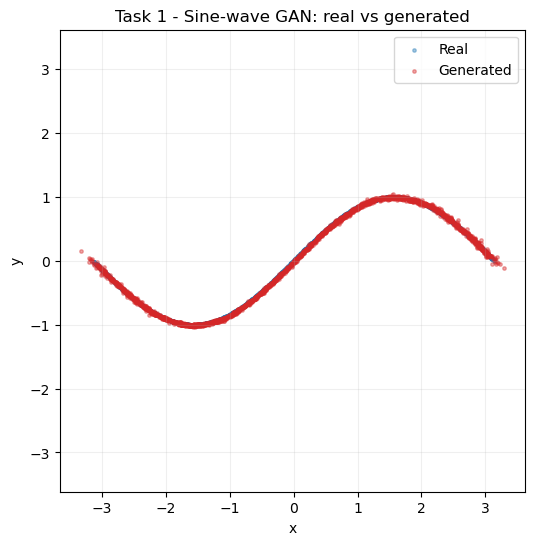

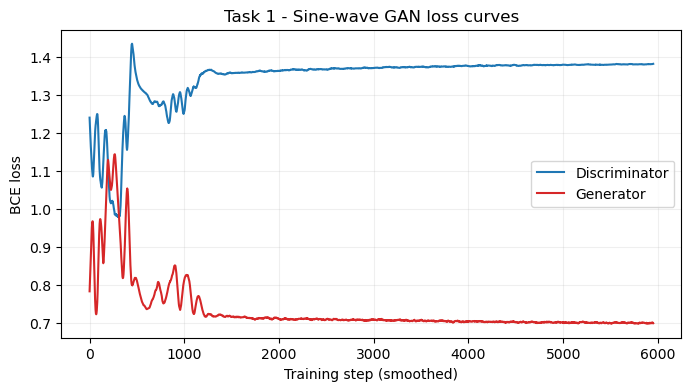

In [10]:
configure_global_reproducibility()
sine_wave_architecture = ArchitectureConfiguration(latent_dimension=16, hidden_width=128, hidden_depth=2, activation_name="relu")

sine_generator, sine_d_losses, sine_g_losses = train_two_dimensional_gan(
    real_data_sampler=sample_sine_wave_distribution, architecture=sine_wave_architecture, number_of_training_steps=6000,
)

sine_real_points = sample_sine_wave_distribution(2000).numpy()
sine_generated_points = draw_generated_2d_samples(sine_generator, sine_wave_architecture, 2000)
plot_real_versus_generated_2d(sine_real_points, sine_generated_points,
    "Task 1 - Sine-wave GAN: real vs generated", os.path.join(RESULTS_DIRECTORY, "part1_task1_sine.png"))
plot_adversarial_loss_curves(sine_d_losses, sine_g_losses,
    "Task 1 - Sine-wave GAN loss curves", os.path.join(RESULTS_DIRECTORY, "part1_task1_sine_loss.png"))

## Task 2: mixture of Gaussians (watch for mode collapse)

step      1/8000 | D=1.4611 | G=0.6652
step   2000/8000 | D=0.9764 | G=1.0190
step   4000/8000 | D=0.8879 | G=1.2157
step   6000/8000 | D=0.7095 | G=1.5478
step   8000/8000 | D=0.9547 | G=1.0874


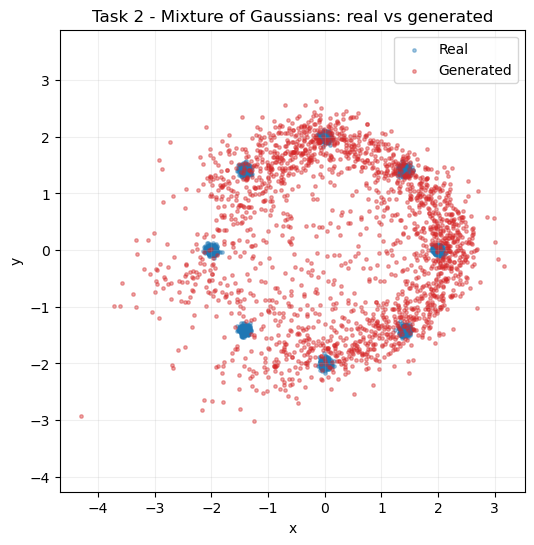

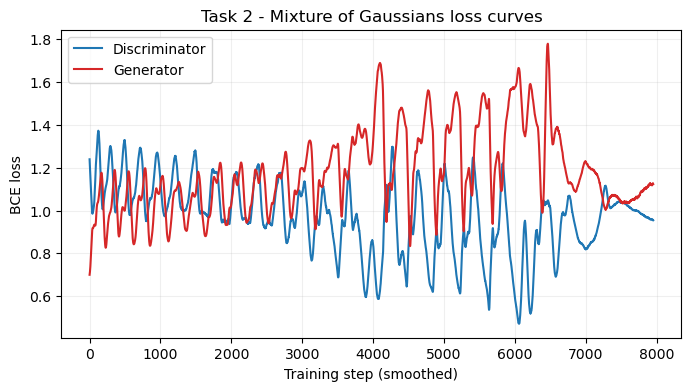

In [11]:
configure_global_reproducibility()
mixture_architecture = ArchitectureConfiguration(latent_dimension=16, hidden_width=128, hidden_depth=2, activation_name="relu")

mixture_generator, mixture_d_losses, mixture_g_losses = train_two_dimensional_gan(
    real_data_sampler=sample_mixture_of_gaussians_distribution, architecture=mixture_architecture, number_of_training_steps=8000,
)

mixture_real_points = sample_mixture_of_gaussians_distribution(2000).numpy()
mixture_generated_points = draw_generated_2d_samples(mixture_generator, mixture_architecture, 2000)
plot_real_versus_generated_2d(mixture_real_points, mixture_generated_points,
    "Task 2 - Mixture of Gaussians: real vs generated", os.path.join(RESULTS_DIRECTORY, "part1_task2_mixture.png"))
plot_adversarial_loss_curves(mixture_d_losses, mixture_g_losses,
    "Task 2 - Mixture of Gaussians loss curves", os.path.join(RESULTS_DIRECTORY, "part1_task2_mixture_loss.png"))

## Task 3: change the architecture and compare

| Architecture | Depth | Width | Activation |
|--------------|-------|-------|------------|
| Baseline | 2 | 128 | ReLU |
| Enhanced | 4 | 256 | SELU |

step      1/8000 | D=1.4611 | G=0.6652
step   2000/8000 | D=0.9764 | G=1.0190
step   4000/8000 | D=0.8879 | G=1.2157
step   6000/8000 | D=0.7095 | G=1.5478
step   8000/8000 | D=0.9547 | G=1.0874
step      1/8000 | D=1.3827 | G=0.8670
step   2000/8000 | D=1.3477 | G=0.9660
step   4000/8000 | D=1.3888 | G=0.8144
step   6000/8000 | D=1.1920 | G=1.0786
step   8000/8000 | D=1.4444 | G=0.8657


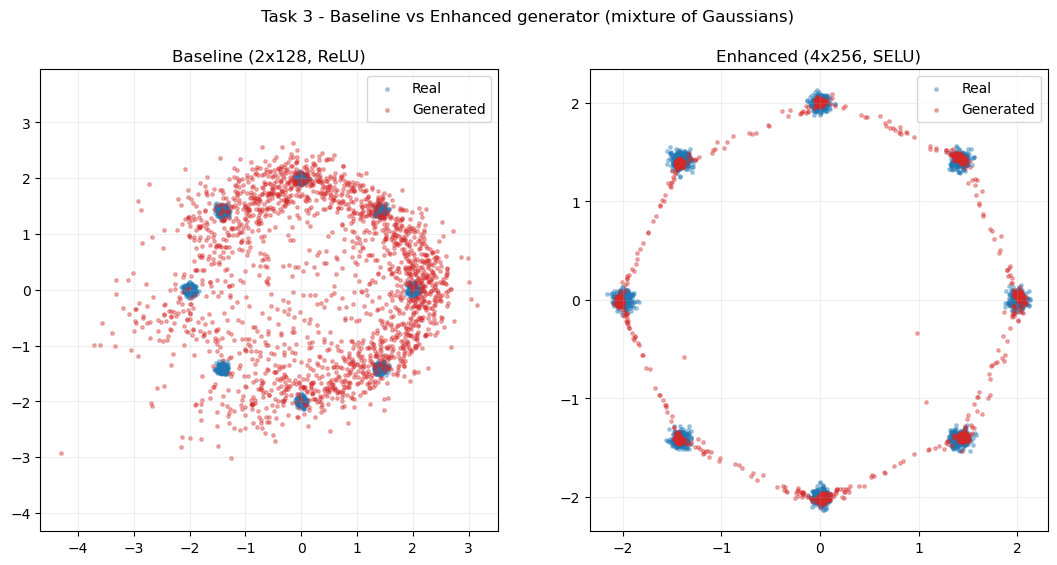

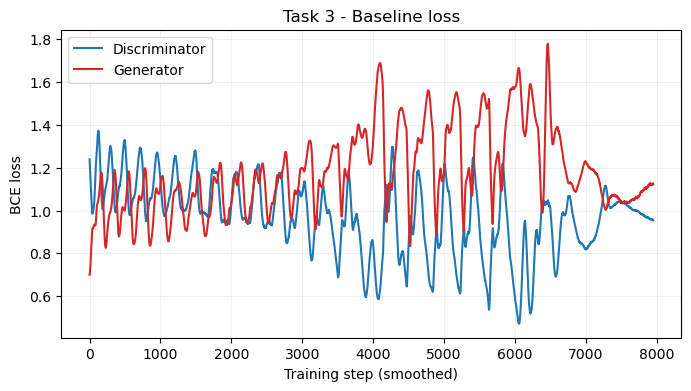

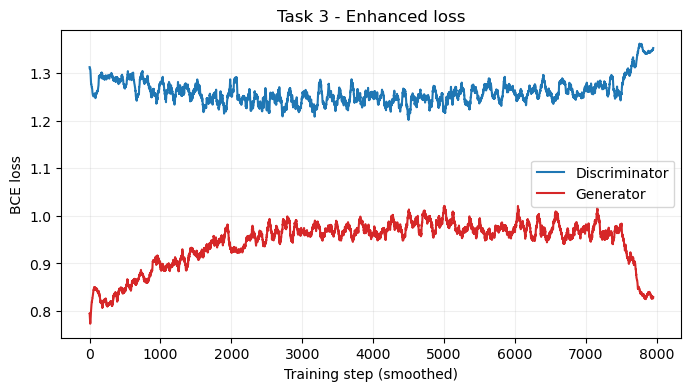

In [12]:
configure_global_reproducibility()
baseline_architecture = ArchitectureConfiguration(hidden_width=128, hidden_depth=2, activation_name="relu")
enhanced_architecture = ArchitectureConfiguration(hidden_width=256, hidden_depth=4, activation_name="selu")

baseline_generator, baseline_d_losses, baseline_g_losses = train_two_dimensional_gan(
    sample_mixture_of_gaussians_distribution, baseline_architecture, number_of_training_steps=8000)

configure_global_reproducibility()
enhanced_generator, enhanced_d_losses, enhanced_g_losses = train_two_dimensional_gan(
    sample_mixture_of_gaussians_distribution, enhanced_architecture, number_of_training_steps=8000)

comparison_real_points = sample_mixture_of_gaussians_distribution(2000).numpy()
baseline_generated_points = draw_generated_2d_samples(baseline_generator, baseline_architecture, 2000)
enhanced_generated_points = draw_generated_2d_samples(enhanced_generator, enhanced_architecture, 2000)

figure, axes = plt.subplots(1, 2, figsize=(13, 6))
for axis, generated_points, subtitle in (
    (axes[0], baseline_generated_points, "Baseline (2x128, ReLU)"),
    (axes[1], enhanced_generated_points, "Enhanced (4x256, SELU)"),
):
    axis.scatter(comparison_real_points[:, 0], comparison_real_points[:, 1], s=6, alpha=0.35, label="Real", color="#1f77b4")
    axis.scatter(generated_points[:, 0], generated_points[:, 1], s=6, alpha=0.35, label="Generated", color="#d62728")
    axis.set_title(subtitle); axis.legend(loc="upper right"); axis.grid(alpha=0.2)
    axis.set_aspect("equal", adjustable="datalim")
figure.suptitle("Task 3 - Baseline vs Enhanced generator (mixture of Gaussians)")
figure.savefig(os.path.join(RESULTS_DIRECTORY, "part1_task3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

plot_adversarial_loss_curves(baseline_d_losses, baseline_g_losses, "Task 3 - Baseline loss", os.path.join(RESULTS_DIRECTORY, "part1_task3_baseline_loss.png"))
plot_adversarial_loss_curves(enhanced_d_losses, enhanced_g_losses, "Task 3 - Enhanced loss", os.path.join(RESULTS_DIRECTORY, "part1_task3_enhanced_loss.png"))

## What the three runs show

A few things stand out. On the sine wave the two losses sit close to their equilibrium values for the whole run (discriminator around 1.38, generator around 0.70) and the generated points land on the `sin(x)` curve with only a little wobble near the turning points, so the basic setup clearly works.

The mixture of Gaussians is the more revealing target. The generator does reach all eight modes rather than parking on one or two, so there is no hard mode collapse, but the samples are noticeably loose: the red cloud fills the ring and some of the gaps between blobs instead of sitting tightly on the eight centres. That is the classic "covers the modes but not sharply" behaviour of a small vanilla GAN.

Task 3 is where the architecture change makes the clearest difference. Holding everything else fixed and moving from a 2x128 ReLU network to a 4x256 SELU one tightens the samples a lot: the enhanced generator concentrates on the eight modes and traces a clean ring, while the baseline stays scattered. So here the extra depth/width and the smoother SELU activation mainly buy sharper, better-localised samples rather than fixing a collapse that never really happened.

# Part 2 - Real-world GAN applications (shared DCGAN core)

Part 2.1 (OCTMNIST) uses the PyTorch DCGAN defined here. Part 2.3 (QuickDraw) is built separately in TensorFlow/Keras later on. Images are worked at 32x32 (a clean power of two for the four conv/transpose stages) and scaled to [-1, 1] to match the generator's final Tanh.

In [13]:
def _build_dcgan_generator_stack(input_channels: int, feature_maps: int, image_channels: int) -> nn.Sequential:
    """ConvTranspose stack: (input_channels,1,1) -> (image_channels,32,32) in [-1,1]."""
    return nn.Sequential(
        nn.ConvTranspose2d(input_channels, feature_maps * 4, 4, 1, 0, bias=False),
        nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),                                  # -> 4x4
        nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),                                  # -> 8x8
        nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps), nn.ReLU(True),                                      # -> 16x16
        nn.ConvTranspose2d(feature_maps, image_channels, 4, 2, 1, bias=False),
        nn.Tanh(),                                                                        # -> 32x32
    )


def _build_dcgan_discriminator_stack(input_channels: int, feature_maps: int) -> nn.Sequential:
    """Conv stack: (input_channels,32,32) -> single logit at (1,1,1)."""
    return nn.Sequential(
        nn.Conv2d(input_channels, feature_maps, 4, 2, 1, bias=False),
        nn.LeakyReLU(0.2, inplace=True),                                                  # -> 16x16
        nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True),                # -> 8x8
        nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True),                # -> 4x4
        nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),                              # -> 1x1 logit
    )


DCGAN_LATENT_DIMENSION = 100


class DcganGenerator(nn.Module):
    """Unconditional DCGAN generator for 32x32 single-channel images."""

    def __init__(self, latent_dimension: int = DCGAN_LATENT_DIMENSION, feature_maps: int = 64, image_channels: int = 1) -> None:
        super().__init__()
        self.network = _build_dcgan_generator_stack(latent_dimension, feature_maps, image_channels)

    def forward(self, latent_noise: Tensor) -> Tensor:
        return self.network(latent_noise)


class DcganDiscriminator(nn.Module):
    """Unconditional DCGAN discriminator returning a raw real/fake logit."""

    def __init__(self, feature_maps: int = 64, image_channels: int = 1) -> None:
        super().__init__()
        self.network = _build_dcgan_discriminator_stack(image_channels, feature_maps)

    def forward(self, images: Tensor) -> Tensor:
        return self.network(images).view(-1, 1)

In [14]:
def preprocess_grayscale_images_to_tensor(images_uint8: np.ndarray, target_size: int = 32) -> Tensor:
    """Convert (N, H, W) uint8 images to (N, 1, target_size, target_size) in [-1, 1]."""
    image_tensor = torch.from_numpy(images_uint8).float().unsqueeze(1)  # (N,1,H,W)
    image_tensor = image_tensor / 127.5 - 1.0                            # -> [-1, 1]
    if image_tensor.shape[-1] != target_size:
        image_tensor = F.interpolate(image_tensor, size=(target_size, target_size), mode="bilinear", align_corners=False)
    return image_tensor


def build_image_dataloader(image_tensor: Tensor, batch_size: int, labels: Tensor | None = None) -> DataLoader:
    """Wrap an image tensor (and optional labels) in a shuffled DataLoader."""
    dataset = TensorDataset(image_tensor, labels) if labels is not None else TensorDataset(image_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)


def build_class_balanced_dataloader(image_tensor: Tensor, class_labels: Tensor, batch_size: int) -> DataLoader:
    """DataLoader that draws every class with equal probability.

    OCTMNIST is very imbalanced (normal is about 6x drusen). Weighting each sample by
    1 / (its class frequency) via WeightedRandomSampler makes the classes appear
    equally often, so the cGAN actually learns the rare ones.
    """
    class_labels_long = class_labels.long()
    per_class_counts = torch.bincount(class_labels_long).float().clamp(min=1.0)
    per_sample_weights = (1.0 / per_class_counts)[class_labels_long]
    balanced_sampler = WeightedRandomSampler(
        weights=per_sample_weights, num_samples=len(class_labels_long), replacement=True,
    )
    dataset = TensorDataset(image_tensor, class_labels_long)
    return DataLoader(dataset, batch_size=batch_size, sampler=balanced_sampler, drop_last=True, num_workers=2)


def train_dcgan(
    generator: DcganGenerator,
    discriminator: DcganDiscriminator,
    dataloader: DataLoader,
    number_of_epochs: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION,
    learning_rate: float = 2e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    figure_prefix: str = "dcgan",
    number_of_progress_snapshots: int = 5,
    real_label_smoothing: float = 0.9,
) -> tuple[list[float], list[float]]:
    """Train an unconditional DCGAN; return (discriminator_losses, generator_losses).

    A fixed noise batch is sampled at several evenly spaced epochs so the report can
    show generated 'visual outputs across epochs', plus a final larger sample grid.
    """
    generator.apply(initialise_dcgan_weights)
    discriminator.apply(initialise_dcgan_weights)

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    fixed_monitoring_noise = torch.randn(64, latent_dimension, 1, 1, device=device)
    fixed_progression_noise = torch.randn(16, latent_dimension, 1, 1, device=device)
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, number_of_epochs, number_of_progress_snapshots)))
    progression_snapshots: list = []
    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []

    for epoch_index in range(1, number_of_epochs + 1):
        for real_image_batch, in dataloader:
            real_image_batch = real_image_batch.to(device)
            current_batch_size = real_image_batch.size(0)

            # discriminator update
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            generated_images = generator(latent_noise).detach()
            real_logits = discriminator(real_image_batch)
            fake_logits = discriminator(generated_images)
            # One-sided label smoothing (real target = 0.9) keeps the discriminator
            # from becoming over-confident, which is the usual cause of D loss -> 0.
            discriminator_loss = (
                binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_smoothing))
                + binary_cross_entropy(fake_logits, torch.zeros_like(fake_logits))
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # generator update
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            generator_logits = discriminator(generator(latent_noise))
            generator_loss = binary_cross_entropy(generator_logits, torch.ones_like(generator_logits))
            generator_optimizer.zero_grad(set_to_none=True)
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_loss_history.append(float(discriminator_loss.item()))
            generator_loss_history.append(float(generator_loss.item()))

        print(f"epoch {epoch_index:>3}/{number_of_epochs} | D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")
        if epoch_index in snapshot_epochs:
            with torch.no_grad():
                progression_snapshots.append((epoch_index, generator(fixed_progression_noise).cpu()))

    # Brief requirement: show generated 'visual outputs across epochs'.
    render_epoch_progression(
        progression_snapshots, f"{figure_prefix}: generated samples across epochs",
        os.path.join(RESULTS_DIRECTORY, f"{figure_prefix}_progression.png"),
    )
    # Plus a final, larger sample grid for the report.
    with torch.no_grad():
        final_monitoring_images = generator(fixed_monitoring_noise)
    plot_image_sample_grid(
        final_monitoring_images, f"{figure_prefix}: generated samples (final epoch)",
        os.path.join(RESULTS_DIRECTORY, f"{figure_prefix}_final_samples.png"),
    )
    return discriminator_loss_history, generator_loss_history


@torch.no_grad()
def generate_dcgan_image_batch(
    generator: DcganGenerator, number_of_images: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION, device: torch.device = COMPUTE_DEVICE,
) -> Tensor:
    """Generate a batch of images in the [-1, 1] range from a trained DCGAN."""
    generator.eval()
    latent_noise = torch.randn(number_of_images, latent_dimension, 1, 1, device=device)
    generated_images = generator(latent_noise).cpu()
    generator.train()
    return generated_images

# Part 2.1 - Medical imaging: OCTMNIST DCGAN

OCTMNIST (from MedMNIST) is 28x28 grayscale OCT retinal scans across four diagnostic classes. The data is explored, a DCGAN is trained to generate retinal scans, and the result is scored with FID.

## Load and explore OCTMNIST

OCTMNIST classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCTMNIST train images: (97477, 28, 28)


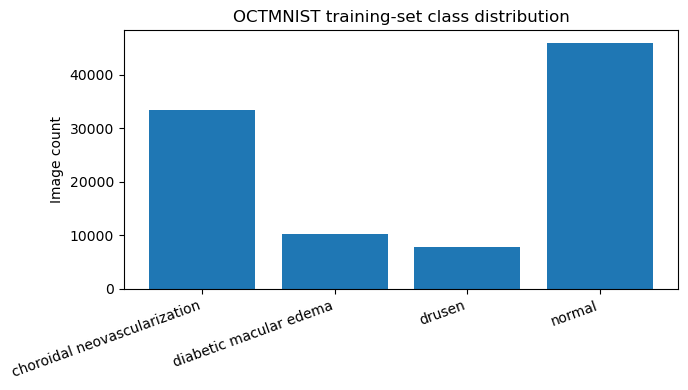

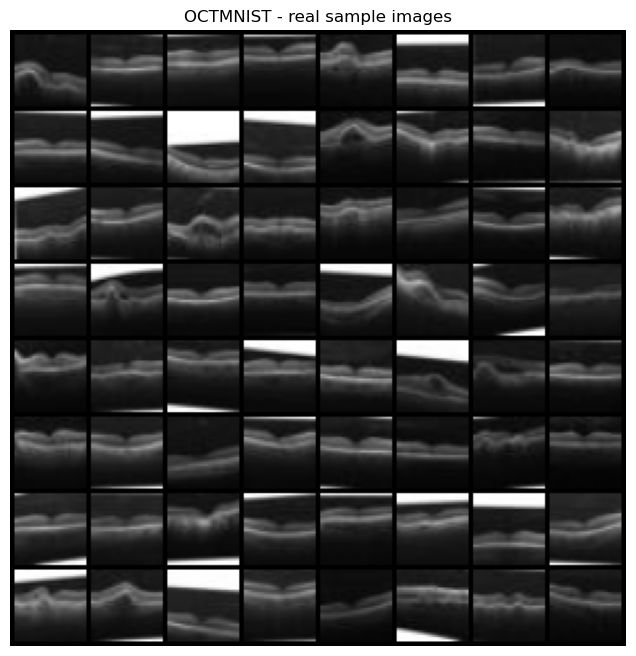

In [16]:
from medmnist import OCTMNIST, INFO

octmnist_metadata = INFO["octmnist"]
octmnist_class_labels = octmnist_metadata["label"]
print("OCTMNIST classes:", octmnist_class_labels)

octmnist_train_dataset = OCTMNIST(split="train", download=True)
octmnist_images_uint8 = octmnist_train_dataset.imgs           # (N, 28, 28) uint8
octmnist_labels = octmnist_train_dataset.labels.flatten()      # (N,) int
print("OCTMNIST train images:", octmnist_images_uint8.shape)

# class distribution
unique_classes, class_counts = np.unique(octmnist_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([octmnist_class_labels[str(int(c))] for c in unique_classes], class_counts, color="#1f77b4")
plt.title("OCTMNIST training-set class distribution")
plt.ylabel("Image count"); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIRECTORY, "octmnist_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# a few real images
real_sample_tensor = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[:64])
plot_image_sample_grid(real_sample_tensor, "OCTMNIST - real sample images",
    os.path.join(RESULTS_DIRECTORY, "octmnist_real_samples.png"))

## Train the OCTMNIST DCGAN

epoch   1/40 | D=0.4706 | G=3.9693
epoch   2/40 | D=1.4307 | G=4.3508
epoch   3/40 | D=0.6750 | G=2.0974
epoch   4/40 | D=0.7115 | G=2.1411
epoch   5/40 | D=0.7817 | G=1.6666
epoch   6/40 | D=0.6351 | G=2.2789
epoch   7/40 | D=0.6426 | G=1.9727
epoch   8/40 | D=0.5691 | G=2.0961
epoch   9/40 | D=0.4888 | G=2.7796
epoch  10/40 | D=0.4530 | G=2.8532
epoch  11/40 | D=0.5055 | G=2.9581
epoch  12/40 | D=0.3861 | G=4.4106
epoch  13/40 | D=1.2662 | G=2.1832
epoch  14/40 | D=0.3944 | G=3.4117
epoch  15/40 | D=0.4003 | G=3.3268
epoch  16/40 | D=2.1220 | G=0.6247
epoch  17/40 | D=0.3899 | G=2.7566
epoch  18/40 | D=0.3665 | G=3.8805
epoch  19/40 | D=0.6445 | G=2.0647
epoch  20/40 | D=0.4637 | G=4.8271
epoch  21/40 | D=0.5159 | G=3.1812
epoch  22/40 | D=0.4591 | G=2.7403
epoch  23/40 | D=0.4036 | G=2.2601
epoch  24/40 | D=0.3430 | G=4.8522
epoch  25/40 | D=0.5159 | G=4.4872
epoch  26/40 | D=0.4140 | G=4.1121
epoch  27/40 | D=0.3529 | G=4.4789
epoch  28/40 | D=0.4853 | G=5.8639
epoch  29/40 | D=0.4

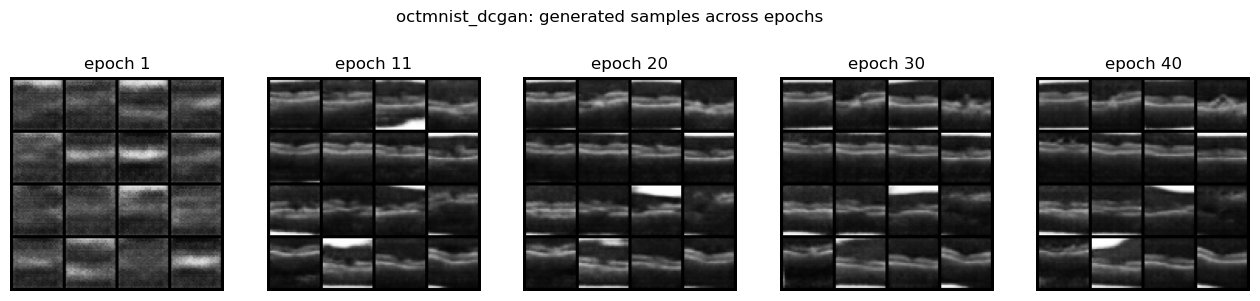

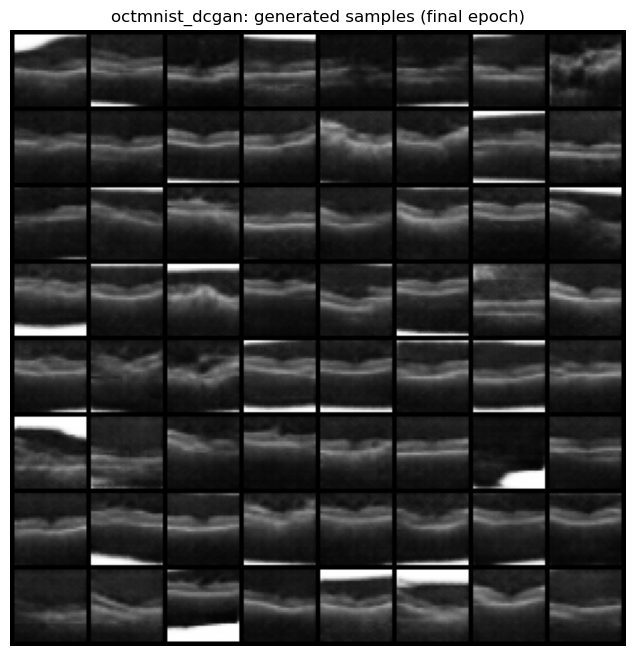

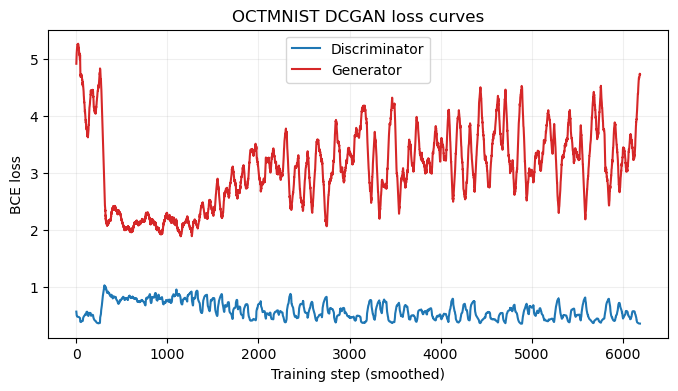

In [17]:
configure_global_reproducibility()

# subsample for a reasonable training time, then preprocess to (N,1,32,32) in [-1,1]
octmnist_subset_indices = np.random.permutation(len(octmnist_images_uint8))[:MAX_IMAGES_PER_DATASET]
octmnist_image_tensor = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[octmnist_subset_indices])
octmnist_dataloader = build_image_dataloader(octmnist_image_tensor, IMAGE_GAN_BATCH_SIZE)

octmnist_generator = maybe_data_parallel(DcganGenerator().to(COMPUTE_DEVICE))
octmnist_discriminator = maybe_data_parallel(DcganDiscriminator().to(COMPUTE_DEVICE))

octmnist_d_losses, octmnist_g_losses = train_dcgan(
    octmnist_generator, octmnist_discriminator, octmnist_dataloader,
    number_of_epochs=IMAGE_GAN_EPOCHS, figure_prefix="octmnist_dcgan",
)
plot_adversarial_loss_curves(octmnist_d_losses, octmnist_g_losses,
    "OCTMNIST DCGAN loss curves", os.path.join(RESULTS_DIRECTORY, "octmnist_loss_curves.png"))

## Real vs fake, and FID

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/ec2-user/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 471MB/s] 


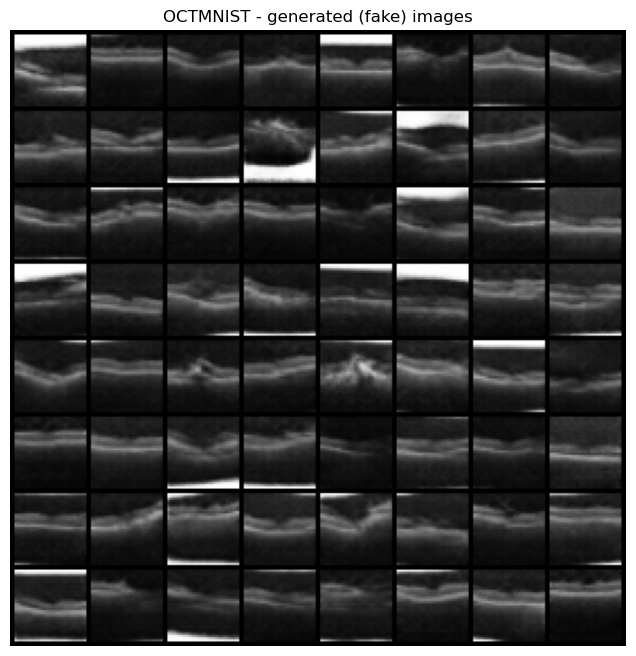

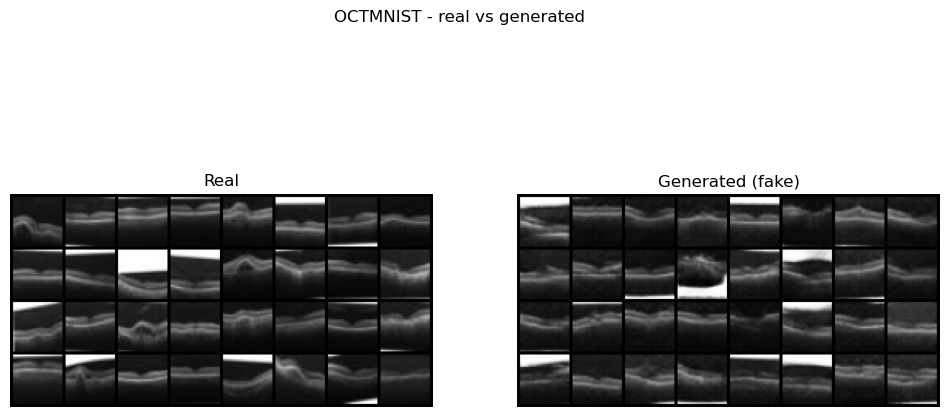

OCTMNIST DCGAN FID (lower is better): 50.38


In [18]:
# build the Inception feature extractor once and reuse it for every FID call
inception_feature_extractor = InceptionFeatureExtractor(COMPUTE_DEVICE)


def convert_tanh_range_to_unit_range(images_tanh_range: Tensor) -> Tensor:
    """Map images from the [-1, 1] tanh range to the [0, 1] range FID expects."""
    return (images_tanh_range.clamp(-1, 1) + 1.0) / 2.0


# generated images for the grid and for FID
octmnist_fake_images = generate_dcgan_image_batch(octmnist_generator, FID_SAMPLE_COUNT)
plot_image_sample_grid(octmnist_fake_images[:64], "OCTMNIST - generated (fake) images",
    os.path.join(RESULTS_DIRECTORY, "octmnist_fake_samples.png"))

# side-by-side real vs fake
octmnist_real_for_display = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[:32])
plot_real_versus_fake_grids(octmnist_real_for_display, octmnist_fake_images[:32],
    "OCTMNIST - real vs generated", os.path.join(RESULTS_DIRECTORY, "octmnist_real_vs_fake.png"))

# a separate real sample for FID, preprocessed the same way
octmnist_fid_real_indices = np.random.permutation(len(octmnist_images_uint8))[:FID_SAMPLE_COUNT]
octmnist_real_for_fid = convert_tanh_range_to_unit_range(
    preprocess_grayscale_images_to_tensor(octmnist_images_uint8[octmnist_fid_real_indices]))
octmnist_fake_for_fid = convert_tanh_range_to_unit_range(octmnist_fake_images)

octmnist_fid_score = compute_frechet_inception_distance(
    octmnist_real_for_fid, octmnist_fake_for_fid, inception_feature_extractor)
print(f"OCTMNIST DCGAN FID (lower is better): {octmnist_fid_score:.2f}")

## Conditional GAN (extension)

A conditional DCGAN lets me ask for a specific class. The label is embedded and then (a) concatenated with the latent vector for the generator and (b) turned into an extra input channel for the discriminator.

A naive version collapses here: the discriminator loss drops to zero, the generator loss blows up, and the output is noise. Three standard fixes address this: one-sided label smoothing (real target 0.9), a two time-scale update rule (TTUR) with a slower discriminator, and class-balanced sampling so the minority classes actually get learned.

In [19]:
class ConditionalDcganGenerator(nn.Module):
    """Class-conditioned DCGAN generator (32x32, single channel)."""

    def __init__(self, number_of_classes: int, latent_dimension: int = DCGAN_LATENT_DIMENSION,
                 feature_maps: int = 64, image_channels: int = 1, label_embedding_dimension: int = 50) -> None:
        super().__init__()
        self.label_embedding = nn.Embedding(number_of_classes, label_embedding_dimension)
        self.network = _build_dcgan_generator_stack(latent_dimension + label_embedding_dimension, feature_maps, image_channels)

    def forward(self, latent_noise: Tensor, class_labels: Tensor) -> Tensor:
        label_vector = self.label_embedding(class_labels).unsqueeze(-1).unsqueeze(-1)  # (N, emb, 1, 1)
        conditioned_input = torch.cat([latent_noise, label_vector], dim=1)
        return self.network(conditioned_input)


class ConditionalDcganDiscriminator(nn.Module):
    """Class-conditioned DCGAN discriminator (label injected as an extra channel)."""

    def __init__(self, number_of_classes: int, feature_maps: int = 64, image_channels: int = 1, image_size: int = 32) -> None:
        super().__init__()
        self.image_size = image_size
        self.label_embedding = nn.Embedding(number_of_classes, image_size * image_size)
        self.network = _build_dcgan_discriminator_stack(image_channels + 1, feature_maps)

    def forward(self, images: Tensor, class_labels: Tensor) -> Tensor:
        label_map = self.label_embedding(class_labels).view(-1, 1, self.image_size, self.image_size)
        conditioned_input = torch.cat([images, label_map], dim=1)
        return self.network(conditioned_input).view(-1, 1)


def train_conditional_dcgan(
    generator: ConditionalDcganGenerator,
    discriminator: ConditionalDcganDiscriminator,
    dataloader: DataLoader,
    number_of_epochs: int,
    number_of_classes: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION,
    generator_learning_rate: float = 2e-4,
    discriminator_learning_rate: float = 1e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    real_label_smoothing: float = 0.9,
) -> tuple[list[float], list[float]]:
    """Train the conditional DCGAN; dataloader must yield (images, labels).

    Three stabilisers prevent the discriminator-collapse (D loss -> 0, G loss -> inf,
    noise output) seen with a naive conditional DCGAN:
      * One-sided label smoothing (real target = 0.9) floors the discriminator loss.
      * TTUR: the discriminator learns slower than the generator
        (``discriminator_learning_rate`` < ``generator_learning_rate``) so it cannot
        overpower the generator early on.
      * The caller supplies a class-balanced dataloader so every class is learned.
    """
    generator.apply(initialise_dcgan_weights)
    discriminator.apply(initialise_dcgan_weights)
    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=generator_learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=discriminator_learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []

    for epoch_index in range(1, number_of_epochs + 1):
        for real_image_batch, real_label_batch in dataloader:
            real_image_batch = real_image_batch.to(device)
            real_label_batch = real_label_batch.to(device).long()
            current_batch_size = real_image_batch.size(0)

            # discriminator update (real target smoothed to 0.9)
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            sampled_labels = torch.randint(0, number_of_classes, (current_batch_size,), device=device)
            generated_images = generator(latent_noise, sampled_labels).detach()
            real_logits = discriminator(real_image_batch, real_label_batch)
            fake_logits = discriminator(generated_images, sampled_labels)
            discriminator_loss = (
                binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_smoothing))
                + binary_cross_entropy(fake_logits, torch.zeros_like(fake_logits))
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # ---- Generator update (target = 1.0, non-saturating) ---- #
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            sampled_labels = torch.randint(0, number_of_classes, (current_batch_size,), device=device)
            generator_logits = discriminator(generator(latent_noise, sampled_labels), sampled_labels)
            generator_loss = binary_cross_entropy(generator_logits, torch.ones_like(generator_logits))
            generator_optimizer.zero_grad(set_to_none=True)
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_loss_history.append(float(discriminator_loss.item()))
            generator_loss_history.append(float(generator_loss.item()))
        print(f"[cGAN] epoch {epoch_index:>3}/{number_of_epochs} | D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")

    return discriminator_loss_history, generator_loss_history

[cGAN] epoch   1/40 | D=0.9376 | G=2.7257
[cGAN] epoch   2/40 | D=0.4744 | G=3.8991
[cGAN] epoch   3/40 | D=0.3988 | G=3.1064
[cGAN] epoch   4/40 | D=0.4000 | G=3.5644
[cGAN] epoch   5/40 | D=0.4758 | G=3.7171
[cGAN] epoch   6/40 | D=1.6881 | G=1.1552
[cGAN] epoch   7/40 | D=1.3034 | G=1.7234
[cGAN] epoch   8/40 | D=1.3025 | G=1.4794
[cGAN] epoch   9/40 | D=1.0105 | G=1.4282
[cGAN] epoch  10/40 | D=1.3661 | G=1.0111
[cGAN] epoch  11/40 | D=1.1770 | G=1.2328
[cGAN] epoch  12/40 | D=1.1475 | G=1.8443
[cGAN] epoch  13/40 | D=1.1701 | G=1.5240
[cGAN] epoch  14/40 | D=1.0176 | G=1.6330
[cGAN] epoch  15/40 | D=1.0125 | G=1.3999
[cGAN] epoch  16/40 | D=1.1402 | G=1.4457
[cGAN] epoch  17/40 | D=1.4640 | G=0.9092
[cGAN] epoch  18/40 | D=1.2736 | G=1.1389
[cGAN] epoch  19/40 | D=1.2513 | G=1.0903
[cGAN] epoch  20/40 | D=1.2054 | G=1.3390
[cGAN] epoch  21/40 | D=1.3048 | G=1.1550
[cGAN] epoch  22/40 | D=0.9795 | G=1.0459
[cGAN] epoch  23/40 | D=1.2112 | G=1.1727
[cGAN] epoch  24/40 | D=0.9565 | G

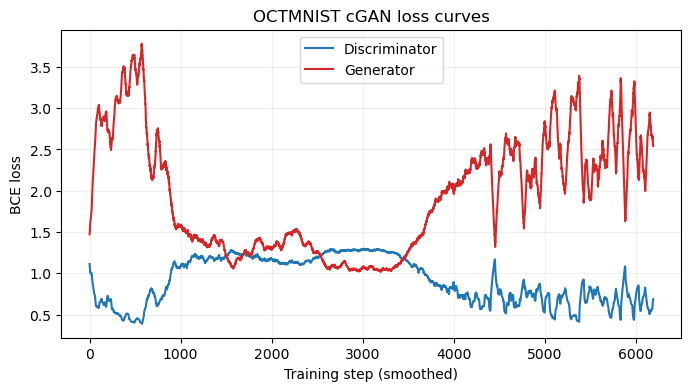

In [20]:
configure_global_reproducibility()
number_of_octmnist_classes = len(octmnist_class_labels)

# Reuse the same subset, this time carrying labels for conditioning.
# Class-balanced sampling counters the OCTMNIST imbalance so every class is learned.
octmnist_label_tensor = torch.from_numpy(octmnist_labels[octmnist_subset_indices]).long()
conditional_dataloader = build_class_balanced_dataloader(octmnist_image_tensor, octmnist_label_tensor, IMAGE_GAN_BATCH_SIZE)

conditional_generator = maybe_data_parallel(ConditionalDcganGenerator(number_of_octmnist_classes).to(COMPUTE_DEVICE))
conditional_discriminator = maybe_data_parallel(ConditionalDcganDiscriminator(number_of_octmnist_classes).to(COMPUTE_DEVICE))

conditional_d_losses, conditional_g_losses = train_conditional_dcgan(
    conditional_generator, conditional_discriminator, conditional_dataloader,
    number_of_epochs=IMAGE_GAN_EPOCHS, number_of_classes=number_of_octmnist_classes)
plot_adversarial_loss_curves(conditional_d_losses, conditional_g_losses,
    "OCTMNIST cGAN loss curves", os.path.join(RESULTS_DIRECTORY, "octmnist_cgan_loss_curves.png"))

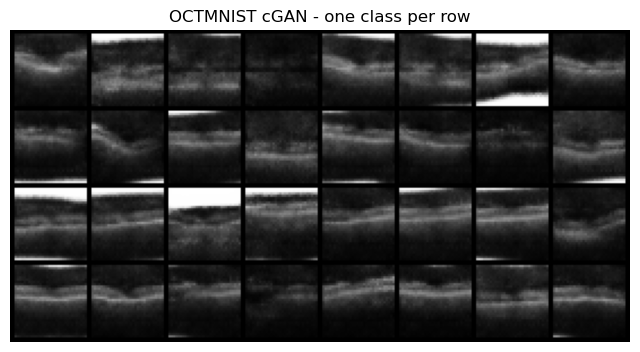

In [21]:
# generate a fixed number per class to show the conditioning works
@torch.no_grad()
def generate_conditional_class_grid(generator: ConditionalDcganGenerator, number_of_classes: int,
                                    images_per_class: int = 8, latent_dimension: int = DCGAN_LATENT_DIMENSION,
                                    device: torch.device = COMPUTE_DEVICE) -> Tensor:
    """Return an (number_of_classes * images_per_class, 1, 32, 32) tensor, row = class."""
    generator.eval()
    per_class_batches = []
    for class_index in range(number_of_classes):
        latent_noise = torch.randn(images_per_class, latent_dimension, 1, 1, device=device)
        class_labels = torch.full((images_per_class,), class_index, dtype=torch.long, device=device)
        per_class_batches.append(generator(latent_noise, class_labels).cpu())
    generator.train()
    return torch.cat(per_class_batches, dim=0)


conditional_class_grid = generate_conditional_class_grid(conditional_generator, number_of_octmnist_classes)
plot_image_sample_grid(conditional_class_grid, "OCTMNIST cGAN - one class per row",
    os.path.join(RESULTS_DIRECTORY, "octmnist_cgan_per_class.png"), grid_row_count=8)

## Reflection

Do the fakes look like real scans? Broadly, yes. The generator picks up the thing that defines an OCT image, the bright curved retinal band over a darker background, and the batch is varied rather than one image repeated, so it hasn't collapsed. Watching the per-epoch grids, the layered structure appears within the first several epochs and then just sharpens. The honest weaknesses are fidelity ones: the fakes are softer than the real scans, the fine sub-layers are smeared, and a few have blocky patches. That fits an FID of 50.38, which is respectable for 40 epochs at 32x32 with an ImageNet Inception scorer that was never built for single-channel medical images. The fixed seed and deterministic cuDNN keep the number stable between runs.

The cGAN extension does give per-class control: asking for a class produces a row of that class, and the class-balanced sampler is what stops the rarer classes (OCTMNIST is roughly 6:1 normal-to-drusen) from being ignored. In fairness the visual gap between the four diagnostic classes is subtle, which is not surprising given how alike these scans look even in the real data.

On "using GANs to generate ducks": the point is hallucination. A GAN will happily invent structure that looks plausible but was never in the data, and in a retinal scan an invented bright region could read as pathology that isn't there. That is the main reason synthetic medical images are fine for augmentation or teaching but shouldn't be handed to anything making a diagnosis.

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017

CICIDS 2017 stores each network flow as about 78 numeric features rather than an image, so the model used here is a fully-connected GAN that follows the same DCGAN training recipe as above: adversarial `BCEWithLogitsLoss`, BatchNorm in the generator, a LeakyReLU discriminator, Adam, and one-sided label smoothing. (A convolutional DCGAN is for images; here the recipe is kept but dense layers are used instead, since the brief asks for feature vectors.)

**Plan (from the brief):** combine the per-day CSVs and explore the class balance, then focus on the Wednesday file (BENIGN vs DoS), train the feature-vector GAN, and compare real vs synthetic with PCA and t-SNE.

> **Data:** put the eight CICIDS 2017 CSVs in one folder and set `CICIDS_DIR` below to it.
>
> **Label note:** the brief says "DDoS", but Wednesday's attacks are single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). The named day is followed and treated as BENIGN vs DoS, with the mismatch noted here for the marker.

## Find the CSV files

In [31]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# The eight day-files sit in one flat folder (no per-day subfolders).
# Point CICIDS_DIR at that folder.
CICIDS_DIR = "."   # <-- set this to the folder with the CSVs

CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
cicids_csv_paths = [os.path.join(CICIDS_DIR, name) for name in CICIDS_CSV_FILES]
missing_files = [p for p in cicids_csv_paths if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError("CICIDS CSV files not found under CICIDS_DIR=%r: %s"
                            % (CICIDS_DIR, [os.path.basename(p) for p in missing_files]))
print(f"Using {len(cicids_csv_paths)} CICIDS 2017 CSV files from: {os.path.abspath(CICIDS_DIR)}")
for csv_path in cicids_csv_paths:
    print("  ", os.path.basename(csv_path))

Using 8 CICIDS 2017 CSV files from: /home/ec2-user/SageMaker
   Monday-WorkingHours.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## Combine every day file and explore

Following the brief, all the day files are merged into one frame (each row tagged with its `SourceDay`) and examined: overall class balance, flows per day, the feature count, how many Inf/NaN values need cleaning, and the attack fraction per day. BENIGN dominates by a large margin, so the class-count plot uses a log scale, and numeric columns are cast to float32 to keep the roughly 2.8M-row frame in memory.

In [32]:
def derive_day_label(csv_path):
    """Get the day-of-week from a CICIDS filename."""
    lower_name = os.path.basename(csv_path).lower()
    for day_name in ("monday", "tuesday", "wednesday", "thursday", "friday"):
        if day_name in lower_name:
            return day_name.capitalize()
    return "Unknown"

# load each day file, tag its rows with the day, and concatenate
day_frames = []
for csv_path in cicids_csv_paths:
    day_frame = pd.read_csv(csv_path, low_memory=False)
    day_frame.columns = day_frame.columns.str.strip()
    day_frame = day_frame.loc[:, ~day_frame.columns.str.startswith("Unnamed")]  # drop stray index columns
    if "Label" not in day_frame.columns:
        print(f"  skipping {os.path.basename(csv_path)} (no Label column)")
        continue
    day_frame_numeric_columns = day_frame.select_dtypes(include=[np.number]).columns
    day_frame[day_frame_numeric_columns] = day_frame[day_frame_numeric_columns].astype(np.float32)  # float32 to halve memory
    day_frame["Label"] = day_frame["Label"].astype(str).str.strip()
    day_frame["SourceDay"] = derive_day_label(csv_path)
    day_frames.append(day_frame)

if not day_frames:
    raise ValueError("No CICIDS day files with a Label column were found - check the dataset was added.")

# join="inner" keeps only columns common to all files, so a schema mismatch can't add
# all-NaN phantom columns that dropna() would later use to wipe good rows.
combined_frame = pd.concat(day_frames, ignore_index=True, join="inner")
del day_frames
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")

Combined dataset: 2,830,743 flows x 80 columns


Overall class distribution (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


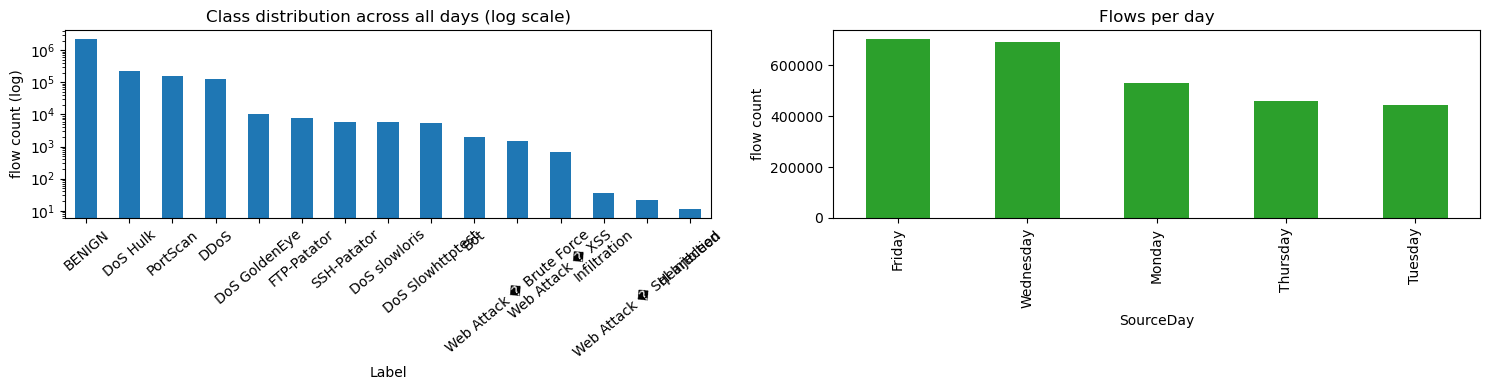

In [33]:
# class balance across all days, and flows per day
overall_class_distribution = combined_frame["Label"].value_counts()
print("Overall class distribution (all days):")
print(overall_class_distribution)

exploration_figure, exploration_axes = plt.subplots(1, 2, figsize=(15, 4))
overall_class_distribution.plot(kind="bar", ax=exploration_axes[0], color="#1f77b4", logy=True)
exploration_axes[0].set_title("Class distribution across all days (log scale)")
exploration_axes[0].set_ylabel("flow count (log)")
exploration_axes[0].tick_params(axis="x", rotation=40)
combined_frame["SourceDay"].value_counts().plot(kind="bar", ax=exploration_axes[1], color="#2ca02c")
exploration_axes[1].set_title("Flows per day")
exploration_axes[1].set_ylabel("flow count")
exploration_figure.tight_layout()
exploration_figure.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# feature overview and a quick data-quality check
numeric_feature_columns = combined_frame.drop(columns=["Label", "SourceDay"]).select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric feature count: {len(numeric_feature_columns)}")
print("First 12 features:", numeric_feature_columns[:12])

numeric_block = combined_frame[numeric_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(numeric_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(numeric_block).sum()):,}")
del numeric_block

# attack fraction per day (which days are attack-heavy)
attack_fraction_per_day = (
    combined_frame.assign(_is_attack=(combined_frame["Label"] != "BENIGN").astype(int))
    .groupby("SourceDay")["_is_attack"].mean().sort_values()
)
print("Fraction of attack flows per day:")
print(attack_fraction_per_day)

Numeric feature count: 78
First 12 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite values across features: 4,376
Missing (NaN) values across features: 1,358
Fraction of attack flows per day:
SourceDay
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: _is_attack, dtype: float64


## Focus on Wednesday (BENIGN vs DoS) and preprocess

Per the brief, the GAN is trained on the Wednesday file only, taken straight from the combined frame. Inf/NaN rows are dropped, a binary BENIGN-vs-DoS target is built, and the numeric features are kept, standardised, then clipped to +/-5 sigma so CICIDS's extreme outliers cannot destabilise training.

In [35]:
wednesday_frame = combined_frame[combined_frame["SourceDay"] == "Wednesday"].copy()
if wednesday_frame.empty:
    raise ValueError("No Wednesday rows found in the combined dataset - check the file names.")

print("Wednesday class balance:")
print(wednesday_frame["Label"].value_counts())

# drop the Inf/NaN rows the flow features introduce
wednesday_frame = wednesday_frame.replace([np.inf, -np.inf], np.nan).dropna()
if wednesday_frame.empty:
    raise ValueError("Wednesday data is empty after Inf/NaN cleaning - unexpected for this dataset.")

# binary target: BENIGN (0) vs any DoS (1)
attack_indicator = (wednesday_frame["Label"] != "BENIGN").astype(int).to_numpy()

# numeric features only; drop the label and day columns so nothing leaks the target
feature_frame = (
    wednesday_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number])
    .astype(np.float32)
)
feature_names = list(feature_frame.columns)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

# standardise, then clip extreme outliers to +/-5 sigma
feature_scaler = StandardScaler().fit(feature_matrix)
scaled_features = np.clip(feature_scaler.transform(feature_matrix), -5.0, 5.0).astype(np.float32)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Feature vectors: 691406 rows x 78 features


In [36]:
configure_global_reproducibility()

# subsample rows to keep training and t-SNE manageable
cicids_max_training_rows = 4000 if QUICK_SMOKE_TEST else 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_max_training_rows]

cicids_training_features = torch.tensor(scaled_features[cicids_row_indices], dtype=torch.float32)
cicids_feature_dimension = cicids_training_features.shape[1]
cicids_dataloader = DataLoader(
    TensorDataset(cicids_training_features), batch_size=256, shuffle=True, drop_last=True, num_workers=2
)
print(f"Training feature-vector GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dimension} features")

Training feature-vector GAN on 20000 rows x 78 features


## The feature-vector GAN (dense layers, DCGAN recipe)

The generator turns latent noise into a full feature vector (BatchNorm + ReLU, with a linear output because the standardised features aren't bounded). The discriminator is a dense LeakyReLU network with dropout that scores a vector as real or synthetic.

In [37]:
CICIDS_LATENT_DIMENSION = 32

class TabularFeatureGenerator(nn.Module):
    """Latent noise -> a synthetic (standardised) CICIDS feature vector."""

    def __init__(self, latent_dimension, feature_dimension):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(latent_dimension, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, feature_dimension),
        )

    def forward(self, latent_noise):
        return self.network(latent_noise)


class TabularFeatureDiscriminator(nn.Module):
    """Scores a feature vector real (high) or synthetic (low) as a raw logit."""

    def __init__(self, feature_dimension):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(feature_dimension, 256), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, feature_vectors):
        return self.network(feature_vectors)

In [38]:
def train_feature_vector_gan(
    dataloader,
    feature_dimension,
    number_of_epochs,
    latent_dimension=CICIDS_LATENT_DIMENSION,
    learning_rate=2e-4,
    adam_betas=(0.5, 0.999),
    real_label_smoothing=0.9,
    device=COMPUTE_DEVICE,
):
    """Train the feature-vector GAN using the DCGAN recipe (BCE + label smoothing)."""
    generator = TabularFeatureGenerator(latent_dimension, feature_dimension).to(device)
    discriminator = TabularFeatureDiscriminator(feature_dimension).to(device)
    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    discriminator_loss_history, generator_loss_history = [], []
    for epoch_index in range(1, number_of_epochs + 1):
        for (real_feature_batch,) in dataloader:
            real_feature_batch = real_feature_batch.to(device)
            current_batch_size = real_feature_batch.size(0)

            # discriminator update (real target smoothed to 0.9)
            latent_noise = torch.randn(current_batch_size, latent_dimension, device=device)
            synthetic_features = generator(latent_noise).detach()
            real_logits = discriminator(real_feature_batch)
            fake_logits = discriminator(synthetic_features)
            discriminator_loss = (
                binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_smoothing))
                + binary_cross_entropy(fake_logits, torch.zeros_like(fake_logits))
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # generator update
            latent_noise = torch.randn(current_batch_size, latent_dimension, device=device)
            generator_logits = discriminator(generator(latent_noise))
            generator_loss = binary_cross_entropy(generator_logits, torch.ones_like(generator_logits))
            generator_optimizer.zero_grad(set_to_none=True)
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_loss_history.append(float(discriminator_loss.item()))
            generator_loss_history.append(float(generator_loss.item()))

        if epoch_index == 1 or epoch_index % 10 == 0:
            print(f"epoch {epoch_index:>3}/{number_of_epochs} | D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")
    return generator, discriminator_loss_history, generator_loss_history

epoch   1/60 | D=1.2509 | G=0.8207
epoch  10/60 | D=1.2502 | G=0.9827
epoch  20/60 | D=1.1564 | G=1.1634
epoch  30/60 | D=1.1000 | G=1.2913
epoch  40/60 | D=1.0737 | G=1.2869
epoch  50/60 | D=1.0694 | G=1.3683
epoch  60/60 | D=1.0799 | G=1.3983


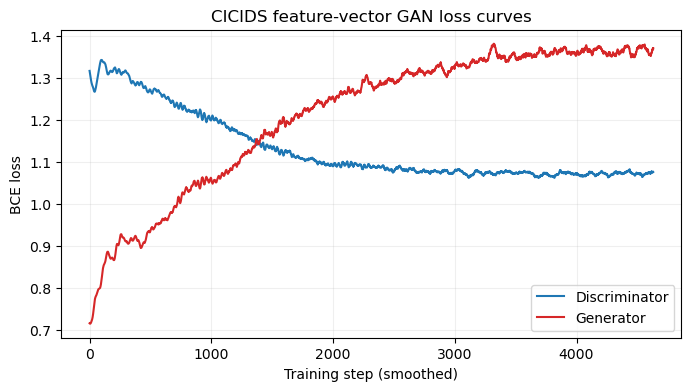

In [39]:
configure_global_reproducibility()
cicids_epochs = 5 if QUICK_SMOKE_TEST else 60
cicids_generator, cicids_discriminator_losses, cicids_generator_losses = train_feature_vector_gan(
    cicids_dataloader, cicids_feature_dimension, number_of_epochs=cicids_epochs
)
plot_adversarial_loss_curves(
    cicids_discriminator_losses, cicids_generator_losses,
    "CICIDS feature-vector GAN loss curves", os.path.join(RESULTS_DIRECTORY, "cicids_loss_curves.png"),
)

## Compare real vs synthetic (PCA and t-SNE)

The real and generated feature vectors are projected down to 2D. PCA gives a quick linear view (real BENIGN, real DoS and synthetic coloured separately) and t-SNE shows the local structure. If the synthetic cloud lands on top of the real ones, the GAN has picked up the distribution.

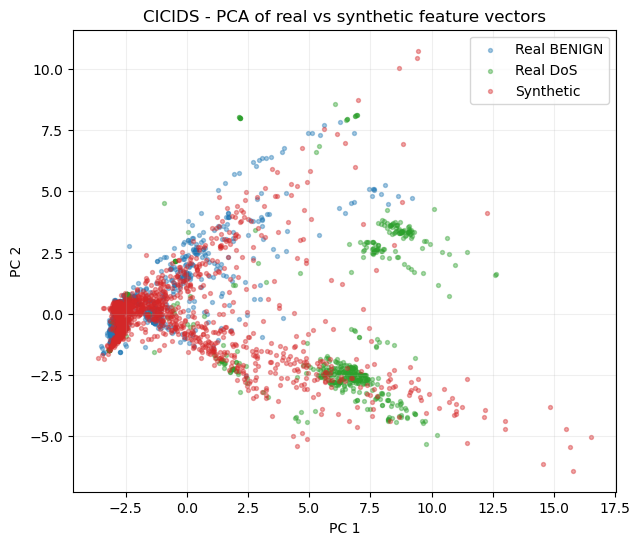

In [40]:
@torch.no_grad()
def generate_synthetic_feature_vectors(generator, count, latent_dimension=CICIDS_LATENT_DIMENSION, device=COMPUTE_DEVICE):
    """Draw synthetic feature vectors from the trained generator."""
    generator.eval()
    latent_noise = torch.randn(count, latent_dimension, device=device)
    synthetic = generator(latent_noise).cpu().numpy()
    generator.train()
    return synthetic

cicids_comparison_sample = 800 if QUICK_SMOKE_TEST else 2000
real_comparison_indices = np.random.permutation(scaled_features.shape[0])[:cicids_comparison_sample]
real_comparison_features = scaled_features[real_comparison_indices]
real_comparison_labels = attack_indicator[real_comparison_indices]
synthetic_comparison_features = generate_synthetic_feature_vectors(cicids_generator, cicids_comparison_sample)

pca_projection = PCA(n_components=2).fit(real_comparison_features)
real_pca = pca_projection.transform(real_comparison_features)
synthetic_pca = pca_projection.transform(synthetic_comparison_features)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[real_comparison_labels == 0, 0], real_pca[real_comparison_labels == 0, 1],
            s=8, alpha=0.4, label="Real BENIGN", color="#1f77b4")
plt.scatter(real_pca[real_comparison_labels == 1, 0], real_pca[real_comparison_labels == 1, 1],
            s=8, alpha=0.4, label="Real DoS", color="#2ca02c")
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], s=8, alpha=0.4, label="Synthetic", color="#d62728")
plt.title("CICIDS - PCA of real vs synthetic feature vectors")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

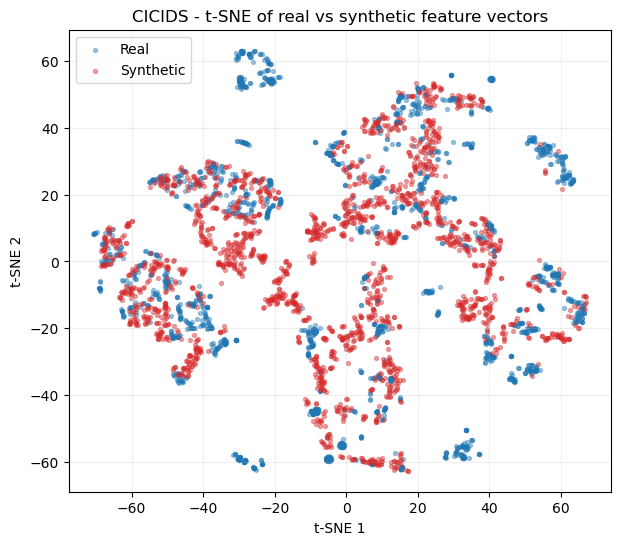

In [41]:
# t-SNE on the stacked real+synthetic vectors, then split them back apart
tsne_inputs = np.vstack([real_comparison_features, synthetic_comparison_features])
tsne_embedding = TSNE(n_components=2, perplexity=30, init="pca", random_state=GLOBAL_RANDOM_SEED).fit_transform(tsne_inputs)
real_tsne = tsne_embedding[:cicids_comparison_sample]
synthetic_tsne = tsne_embedding[cicids_comparison_sample:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#1f77b4")
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], s=8, alpha=0.4, label="Synthetic", color="#d62728")
plt.title("CICIDS - t-SNE of real vs synthetic feature vectors")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# quick quantitative check: per-feature mean and std gaps (standardised space)
real_feature_means, synthetic_feature_means = real_comparison_features.mean(0), synthetic_comparison_features.mean(0)
real_feature_stds, synthetic_feature_stds = real_comparison_features.std(0), synthetic_comparison_features.std(0)
mean_gap = float(np.mean(np.abs(real_feature_means - synthetic_feature_means)))
std_gap = float(np.mean(np.abs(real_feature_stds - synthetic_feature_stds)))
print(f"Mean |mean-gap| across features (standardised): {mean_gap:.4f}")
print(f"Mean |std-gap|  across features (standardised): {std_gap:.4f}")
print("(Values near 0 mean the synthetic feature statistics match the real ones.)")

Mean |mean-gap| across features (standardised): 0.1057
Mean |std-gap|  across features (standardised): 0.1975
(Values near 0 mean the synthetic feature statistics match the real ones.)


## How well does the synthetic traffic match?

Reading the PCA and t-SNE together, the synthetic feature vectors sit right on top of the dense BENIGN region and push part of the way into the DoS clusters without fully reproducing their separate structure. The numbers say the same thing more precisely: an average absolute gap of 0.1057 on the per-feature means and 0.1975 on the standard deviations (in standardised units). So the generator matches where most of the traffic lives and the typical feature values quite well, but it comes out smoother than the real data and doesn't reach the DoS tails, which is the usual story for a plain unconditional GAN on heavy-tailed, partly-binary network features.

## All days and generalisation (extension)

For extra credit, the same feature-vector GAN is trained on the full CICIDS 2017 set (all days, every attack type) instead of Wednesday alone, to check how well it spreads across the attack families. The real points are coloured by family in the PCA/t-SNE, so it is clear whether the synthetic samples cover the whole multi-modal structure or just fall back on BENIGN.

In [43]:
def map_attack_family(label):
    """Collapse the fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


configure_global_reproducibility()

# clean the full combined dataset (all days) and build its feature matrix
full_frame = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_attack_families = full_frame["Label"].map(map_attack_family).to_numpy()
full_feature_frame = (
    full_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number])
    .astype(np.float32)
)
full_feature_matrix = full_feature_frame.to_numpy()
print(f"Full dataset feature vectors: {full_feature_matrix.shape[0]:,} rows x {full_feature_matrix.shape[1]} features")

# standardise + clip with a scaler fit on the full dataset (different scale to Wednesday)
full_feature_scaler = StandardScaler().fit(full_feature_matrix)
full_scaled_features = np.clip(full_feature_scaler.transform(full_feature_matrix), -5.0, 5.0).astype(np.float32)
del full_frame, full_feature_frame, full_feature_matrix   # free memory; arrays retained below

# subsample rows from all days for training
full_max_training_rows = 6000 if QUICK_SMOKE_TEST else 30000
full_row_indices = np.random.permutation(full_scaled_features.shape[0])[:full_max_training_rows]
full_training_features = torch.tensor(full_scaled_features[full_row_indices], dtype=torch.float32)
full_dataloader = DataLoader(
    TensorDataset(full_training_features), batch_size=256, shuffle=True, drop_last=True, num_workers=2
)
print(f"Training the feature-vector GAN on {full_training_features.shape[0]} rows sampled from all days")

Full dataset feature vectors: 2,827,876 rows x 78 features
Training the feature-vector GAN on 30000 rows sampled from all days


epoch   1/60 | D=1.3380 | G=0.8500
epoch  10/60 | D=1.1779 | G=1.0305
epoch  20/60 | D=1.1446 | G=1.1620
epoch  30/60 | D=1.1569 | G=1.2276
epoch  40/60 | D=1.1002 | G=1.2077
epoch  50/60 | D=1.0816 | G=1.2401
epoch  60/60 | D=1.0985 | G=1.2358


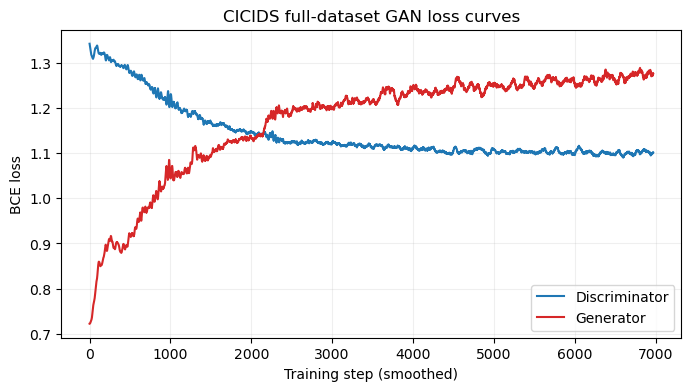

In [44]:
configure_global_reproducibility()
full_dataset_epochs = 5 if QUICK_SMOKE_TEST else 60
full_generator, full_discriminator_losses, full_generator_losses = train_feature_vector_gan(
    full_dataloader, full_training_features.shape[1], number_of_epochs=full_dataset_epochs
)
plot_adversarial_loss_curves(
    full_discriminator_losses, full_generator_losses,
    "CICIDS full-dataset GAN loss curves", os.path.join(RESULTS_DIRECTORY, "cicids_full_loss_curves.png"),
)

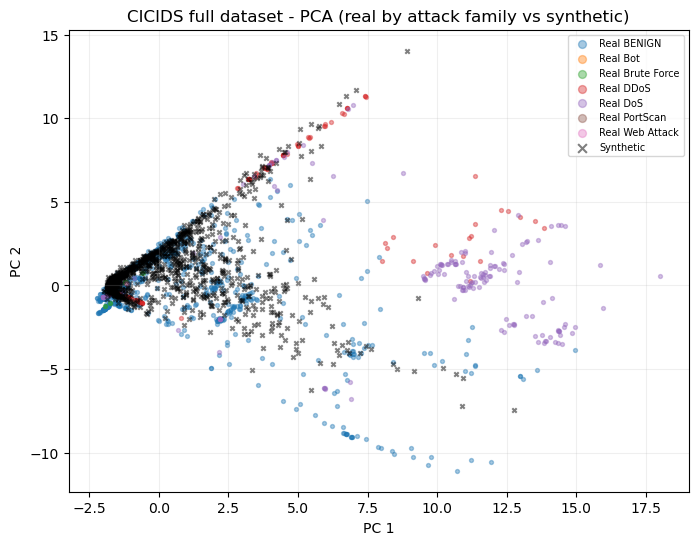

In [45]:
# Real (coloured by attack family) vs synthetic in PCA space.
full_comparison_sample = 800 if QUICK_SMOKE_TEST else 2500
full_real_indices = np.random.permutation(full_scaled_features.shape[0])[:full_comparison_sample]
full_real_features = full_scaled_features[full_real_indices]
full_real_families = full_attack_families[full_real_indices]
full_synthetic_features = generate_synthetic_feature_vectors(full_generator, full_comparison_sample)

full_pca_projection = PCA(n_components=2).fit(full_real_features)
full_real_pca = full_pca_projection.transform(full_real_features)
full_synthetic_pca = full_pca_projection.transform(full_synthetic_features)

plt.figure(figsize=(8, 6))
for family in sorted(set(full_real_families)):
    family_mask = full_real_families == family
    plt.scatter(full_real_pca[family_mask, 0], full_real_pca[family_mask, 1], s=8, alpha=0.4, label=f"Real {family}")
plt.scatter(full_synthetic_pca[:, 0], full_synthetic_pca[:, 1], s=10, alpha=0.5, label="Synthetic", color="black", marker="x")
plt.title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_full_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

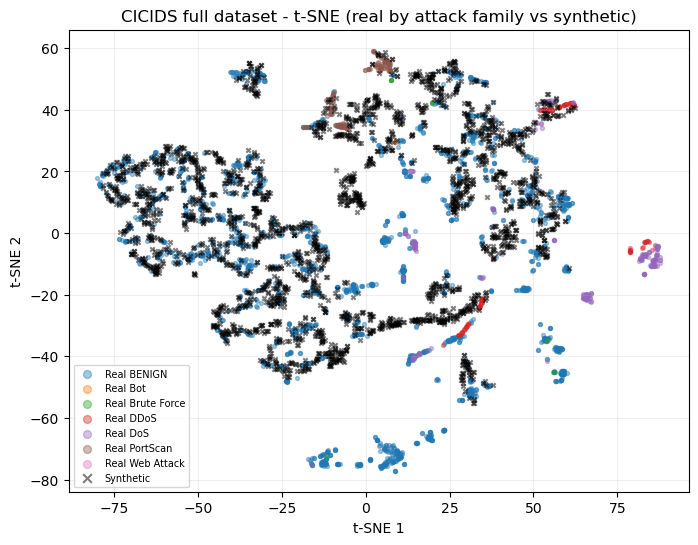

In [46]:
# Same comparison via t-SNE (non-linear view of the multi-modal structure).
full_tsne_inputs = np.vstack([full_real_features, full_synthetic_features])
full_tsne_embedding = TSNE(n_components=2, perplexity=30, init="pca", random_state=GLOBAL_RANDOM_SEED).fit_transform(full_tsne_inputs)
full_real_tsne = full_tsne_embedding[:full_comparison_sample]
full_synthetic_tsne = full_tsne_embedding[full_comparison_sample:]

plt.figure(figsize=(8, 6))
for family in sorted(set(full_real_families)):
    family_mask = full_real_families == family
    plt.scatter(full_real_tsne[family_mask, 0], full_real_tsne[family_mask, 1], s=8, alpha=0.4, label=f"Real {family}")
plt.scatter(full_synthetic_tsne[:, 0], full_synthetic_tsne[:, 1], s=10, alpha=0.5, label="Synthetic", color="black", marker="x")
plt.title("CICIDS full dataset - t-SNE (real by attack family vs synthetic)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_full_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

In [47]:
# alignment on the full dataset, plus which families the sample actually covers
full_real_means, full_synthetic_means = full_real_features.mean(0), full_synthetic_features.mean(0)
full_real_stds, full_synthetic_stds = full_real_features.std(0), full_synthetic_features.std(0)
full_mean_gap = float(np.mean(np.abs(full_real_means - full_synthetic_means)))
full_std_gap = float(np.mean(np.abs(full_real_stds - full_synthetic_stds)))
print(f"Full-dataset mean |mean-gap|: {full_mean_gap:.4f} (Wednesday-only was {mean_gap:.4f})")
print(f"Full-dataset mean |std-gap| : {full_std_gap:.4f} (Wednesday-only was {std_gap:.4f})")

family_names, family_counts = np.unique(full_real_families, return_counts=True)
print("Attack families represented in the comparison sample:")
for family_name, family_count in zip(family_names, family_counts):
    print(f"  {family_name:>14}: {family_count}")

Full-dataset mean |mean-gap|: 0.1017 (Wednesday-only was 0.1057)
Full-dataset mean |std-gap| : 0.2762 (Wednesday-only was 0.1975)
Attack families represented in the comparison sample:
          BENIGN: 2042
             Bot: 2
     Brute Force: 11
            DDoS: 108
             DoS: 210
        PortScan: 125
      Web Attack: 2


## Discussion (extension)

Trained on all days at once the picture is a lot more crowded. The real data now spans BENIGN plus DoS, DDoS, PortScan, Brute Force, Web Attack, Bot and the very rare Infiltration and Heartbleed, and in the PCA/t-SNE the single synthetic cloud clearly leans toward the dominant BENIGN mode and the big attack blobs while barely touching the rare families. In the comparison sample there are only a couple of Bot and Web Attack points and eleven Brute Force, so there is very little of those for the generator to latch onto in the first place.

The gap numbers are interesting. The average mean-gap actually edges down slightly on the full set (0.1017 vs 0.1057 on Wednesday) while the std-gap grows (0.2762 vs 0.1975). Put together: with far more data the generator pins the average feature values a touch better, but it can't stretch to cover the extra spread that all those attack families bring in, so it under-represents their variance. That is the expected result. A single unconditional GAN doesn't generalise cleanly across many attack types, and a class-conditional GAN (like the OCT cGAN earlier) or one model per family would be the way to give the rare attacks their own capacity.

On the "ducks" point again: a GAN can emit a flow that looks entirely plausible but matches no real attack pattern, and if that were used to augment an IDS it could teach the detector to trust something fabricated. For security that's a genuine risk, not just a curiosity.

## TensorFlow/Keras setup (the `Model.fit` style)

The Keras GAN in Part 2.3 is written in the high-level object-oriented way: the generator and discriminator are built with the functional API, wrapped in a `keras.Model` subclass whose `train_step` does the adversarial update, and trained with `model.fit`. FID uses a small `InceptionFidScorer` class.

In [22]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

for _device in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_device, True)
    except Exception:
        pass

KERAS_SEED = 2024
keras.utils.set_random_seed(KERAS_SEED)

KERAS_RESULTS_DIR = "results_set2"
os.makedirs(KERAS_RESULTS_DIR, exist_ok=True)
import matplotlib.pyplot as plt
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| ->", KERAS_RESULTS_DIR)

TensorFlow 2.21.0 | Keras 3.12.3 | -> results_set2


In [23]:
# Functional-API DCGAN builders: Conv2DTranspose generator, strided-Conv2D discriminator.
def make_generator(latent_dim, base_filters=64, init_std=0.02):
    """Functional-API DCGAN generator: (latent,) -> (32, 32, 1) in [-1, 1]."""
    weight_init = keras.initializers.RandomNormal(stddev=init_std)
    latent = keras.Input(shape=(latent_dim,), name="latent")
    x = layers.Dense(4 * 4 * base_filters * 4, use_bias=False, kernel_initializer=weight_init)(latent)
    x = layers.Reshape((4, 4, base_filters * 4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    for filters in (base_filters * 2, base_filters):
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding="same", use_bias=False,
                                   kernel_initializer=weight_init)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False,
                                   activation="tanh", kernel_initializer=weight_init)(x)
    return keras.Model(latent, image, name="generator")


def make_discriminator(base_filters=64, init_std=0.02, dropout=0.3):
    """Functional-API DCGAN discriminator: (32, 32, 1) -> logit."""
    weight_init = keras.initializers.RandomNormal(stddev=init_std)
    image = keras.Input(shape=(32, 32, 1), name="image")
    x = image
    for i, filters in enumerate((base_filters, base_filters * 2, base_filters * 4)):
        x = layers.Conv2D(filters, 4, strides=2, padding="same", kernel_initializer=weight_init)(x)
        if i > 0:
            x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout)(x)
    logit = layers.Dense(1, kernel_initializer=weight_init)(x)
    return keras.Model(image, logit, name="discriminator")

In [24]:
# DCGAN as a keras.Model subclass, trained with model.fit rather than a manual loop.
class DcganModel(keras.Model):
    """DCGAN whose train_step does one discriminator update then one generator update."""

    def __init__(self, generator, discriminator, latent_dim, label_smoothing=0.9):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.label_smoothing = label_smoothing
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        if isinstance(real_images, (tuple, list)):
            real_images = real_images[0]
        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal((batch_size, self.latent_dim))
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            generated = self.generator(noise, training=True)
            real_logits = self.discriminator(real_images, training=True)
            fake_logits = self.discriminator(generated, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logits) * self.label_smoothing, real_logits)
                      + self.loss_fn(tf.zeros_like(fake_logits), fake_logits))
            g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)
        self.d_optimizer.apply_gradients(
            zip(d_tape.gradient(d_loss, self.discriminator.trainable_variables),
                self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(
            zip(g_tape.gradient(g_loss, self.generator.trainable_variables),
                self.generator.trainable_variables))
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}

    def synthesize(self, count):
        return self.generator(tf.random.normal((count, self.latent_dim)), training=False).numpy()


class EpochSampleLogger(keras.callbacks.Callback):
    """Callback that stores a fixed-noise sample grid at a few evenly spaced epochs."""

    def __init__(self, latent_dim, total_epochs, num_snapshots=5):
        super().__init__()
        self.fixed_noise = tf.random.normal((16, latent_dim))
        self.snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, total_epochs, num_snapshots)))
        self.snapshots = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.snapshot_epochs:
            images = self.model.generator(self.fixed_noise, training=False).numpy()
            self.snapshots.append((epoch + 1, images))

In [25]:
# Class-based FID scorer plus a couple of image helpers.
class InceptionFidScorer:
    """FID from InceptionV3 pooled features (ImageNet weights)."""

    def __init__(self):
        self.backbone = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet", input_shape=(299, 299, 3))

    def _embed(self, images_unit, batch=50):
        chunks = []
        for start in range(0, images_unit.shape[0], batch):
            block = tf.image.resize(tf.convert_to_tensor(images_unit[start:start + batch], tf.float32), (299, 299))
            block = tf.repeat(block, 3, axis=-1) if block.shape[-1] == 1 else block
            block = keras.applications.inception_v3.preprocess_input(block * 255.0)
            chunks.append(self.backbone(block, training=False).numpy())
        return np.concatenate(chunks, axis=0)

    def score(self, real_unit, fake_unit, eps=1e-6):
        from scipy import linalg
        real_embed, fake_embed = self._embed(real_unit), self._embed(fake_unit)
        mu_r, mu_f = real_embed.mean(0), fake_embed.mean(0)
        cov_r, cov_f = np.cov(real_embed, rowvar=False), np.cov(fake_embed, rowvar=False)
        covmean = linalg.sqrtm(cov_r.dot(cov_f))
        if isinstance(covmean, tuple):
            covmean = covmean[0]
        if not np.isfinite(covmean).all():
            covmean = linalg.sqrtm((cov_r + np.eye(cov_r.shape[0]) * eps).dot(cov_f + np.eye(cov_f.shape[0]) * eps))
            if isinstance(covmean, tuple):
                covmean = covmean[0]
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        return float(np.sum((mu_r - mu_f) ** 2) + np.trace(cov_r + cov_f - 2.0 * covmean))


def images_from_uint8(images_uint8, size=32):
    """(N, H, W) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = images_uint8.astype("float32")[..., None] / 127.5 - 1.0
    if scaled.shape[1] != size:
        scaled = tf.image.resize(scaled, (size, size)).numpy().astype("float32")
    return scaled


def unit_from_signed(images_signed):
    return (np.clip(images_signed, -1.0, 1.0) + 1.0) / 2.0


def montage(images_signed, title, path=None, per_row=8):
    grid = unit_from_signed(np.asarray(images_signed))
    count = grid.shape[0]
    rows = int(np.ceil(count / per_row))
    canvas = np.ones((rows * 32, per_row * 32))
    for i in range(count):
        r, c = divmod(i, per_row)
        canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
    plt.figure(figsize=(per_row, rows))
    plt.imshow(canvas, cmap="gray"); plt.title(title); plt.axis("off")
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def side_by_side(real_signed, fake_signed, title, path=None, shown=16):
    figure, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    for axis, batch, name in ((axes[0], real_signed, "Real"), (axes[1], fake_signed, "Generated")):
        grid = unit_from_signed(np.asarray(batch)[:shown]); side = int(np.ceil(np.sqrt(grid.shape[0])))
        canvas = np.ones((side * 32, side * 32))
        for i in range(grid.shape[0]):
            r, c = divmod(i, side)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def show_progression(snapshots, title, path=None):
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.0 * len(snapshots), 3.2))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch, batch) in zip(axes, snapshots):
        grid = unit_from_signed(np.asarray(batch)[:16])
        canvas = np.ones((4 * 32, 4 * 32))
        for i in range(min(16, grid.shape[0])):
            r, c = divmod(i, 4)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(f"epoch {epoch}"); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.3 - Creative AI: QuickDraw 'birthday cake' DCGAN (Keras, `Model.fit`)

QuickDraw 'numpy bitmap' sketches are 28x28 grayscale. A Keras DCGAN is trained in the `model.fit` style (the `DcganModel` subclass), scored with FID, and extended to other categories to see how sketch complexity affects the result.

In [26]:
# --- Part 2.3 configuration (QuickDraw DCGAN, Keras Model.fit) ---
CAKE_LATENT = 100
CAKE_BASE = 48
CAKE_LR = 0.00015
CAKE_BETA1 = 0.5
CAKE_EPOCHS = 35
CAKE_BATCH = 256
CAKE_MAX_IMAGES = 30000
CAKE_FID_SAMPLES = 2000
CAKE_INIT_STD = 0.02
CAKE_EXTRA = ['cat', 'house']
print("QuickDraw Keras config:", dict(latent=CAKE_LATENT, base=CAKE_BASE, lr=CAKE_LR,
                                      epochs=CAKE_EPOCHS, batch=CAKE_BATCH, init_std=CAKE_INIT_STD))

QuickDraw Keras config: {'latent': 100, 'base': 48, 'lr': 0.00015, 'epochs': 35, 'batch': 256, 'init_std': 0.02}


## Download and explore 'birthday cake'

fetching birthday cake
birthday cake sketches: (144982, 28, 28)


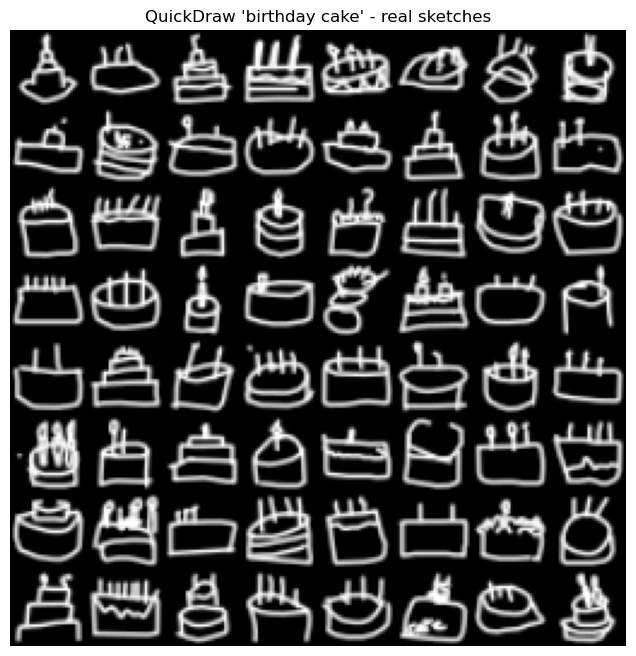

In [27]:
import urllib.request

QUICKDRAW_DIR = os.path.join(KERAS_RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)

def fetch_category(name):
    """Fetch one QuickDraw numpy-bitmap category as (N, 28, 28) uint8. Needs internet."""
    target = os.path.join(QUICKDRAW_DIR, name.replace(" ", "_") + ".npy")
    if not os.path.exists(target):
        source = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/" + name.replace(" ", "%20") + ".npy"
        print("fetching", name)
        request = urllib.request.Request(source, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(target, "wb") as handle:
            handle.write(response.read())
    return np.load(target).reshape(-1, 28, 28)


def ink_fraction(images_uint8, threshold=50):
    """Mean fraction of inked pixels, used as a rough complexity proxy."""
    return float((images_uint8 > threshold).mean())


cake_uint8 = fetch_category("birthday cake")
print("birthday cake sketches:", cake_uint8.shape)
montage(images_from_uint8(cake_uint8[:64]), "QuickDraw 'birthday cake' - real sketches",
        os.path.join(KERAS_RESULTS_DIR, "quickdraw_real_samples.png"))

## Build and train the DCGAN with `model.fit`

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent (InputLayer)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3072)           │       307,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 96)       │       294,912 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 48)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │           768 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,952 (2.59 MB)

 Trainable params: 677,280 (2.58 MB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/35
117/117 - 15s - 126ms/step - d_loss: 0.5456 - g_loss: 2.8397
Epoch 2/35
117/117 - 1s - 10ms/step - d_loss: 0.3968 - g_loss: 4.4297
Epoch 3/35
117/117 - 1s - 10ms/step - d_loss: 0.4340 - g_loss: 4.4818
Epoch 4/35
117/117 - 1s - 10ms/step - d_loss: 0.4505 - g_loss: 4.1165
Epoch 5/35
117/117 - 1s - 10ms/step - d_loss: 0.5204 - g_loss: 3.2030
Epoch 6/35
117/117 - 1s - 10ms/step - d_loss: 0.5944 - g_loss: 2.8205
Epoch 7/35
117/117 - 1s - 10ms/step - d_loss: 0.6269 - g_loss: 2.7163
Epoch 8/35
117/117 - 1s - 10ms/step - d_loss: 0.6203 - g_loss: 2.7142
Epoch 9/35
117/117 - 1s - 10ms/step - d_loss: 0.6204 - g_loss: 2.6827
Epoch 10/35
117/117 - 1s - 10ms/step - d_loss: 0.6341 - g_loss: 2.7024
Epoch 11/35
117/117 - 1s - 10ms/step - d_loss: 0.6153 - g_loss: 2.7182
Epoch 12/35
117/117 - 1s - 10ms/step - d_loss: 0.6459 - g_loss: 2.7075
Epoch 13/35
117/117 - 1s - 10ms/step - d_loss: 0.5801 - g_loss: 2.7449
Epoch 14/35
117/117 - 1s - 10ms/step - d_loss: 0.6506 - g_loss: 2.6772
Epoch 15/35
1

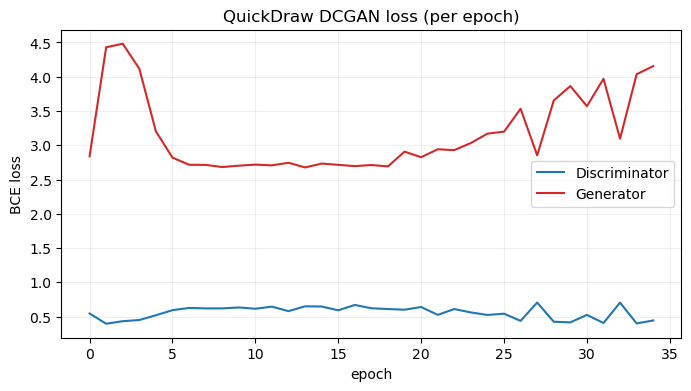

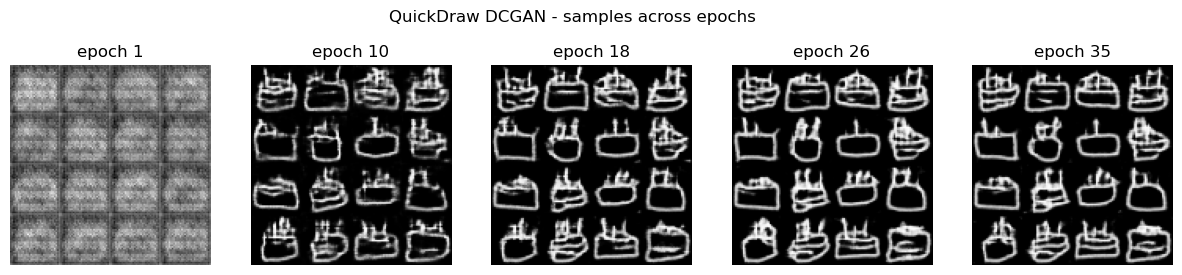

In [28]:
keras.utils.set_random_seed(KERAS_SEED)

cake_indices = np.random.permutation(len(cake_uint8))[:CAKE_MAX_IMAGES]
cake_dataset = (tf.data.Dataset.from_tensor_slices(images_from_uint8(cake_uint8[cake_indices]))
                .shuffle(min(len(cake_indices), 10000))
                .batch(CAKE_BATCH, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))

cake_gan = DcganModel(make_generator(CAKE_LATENT, CAKE_BASE, CAKE_INIT_STD),
                      make_discriminator(CAKE_BASE, CAKE_INIT_STD),
                      latent_dim=CAKE_LATENT)
cake_gan.compile(
    d_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
    g_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True))
cake_gan.generator.summary()

cake_logger = EpochSampleLogger(CAKE_LATENT, CAKE_EPOCHS)
cake_history = cake_gan.fit(cake_dataset, epochs=CAKE_EPOCHS, callbacks=[cake_logger], verbose=2)

plt.figure(figsize=(8, 4))
plt.plot(cake_history.history["d_loss"], label="Discriminator", color="#1f77b4")
plt.plot(cake_history.history["g_loss"], label="Generator", color="#d62728")
plt.title("QuickDraw DCGAN loss (per epoch)"); plt.xlabel("epoch"); plt.ylabel("BCE loss")
plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(KERAS_RESULTS_DIR, "quickdraw_loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
show_progression(cake_logger.snapshots, "QuickDraw DCGAN - samples across epochs",
                 os.path.join(KERAS_RESULTS_DIR, "quickdraw_progression.png"))

## Generate, compare against real, and score FID

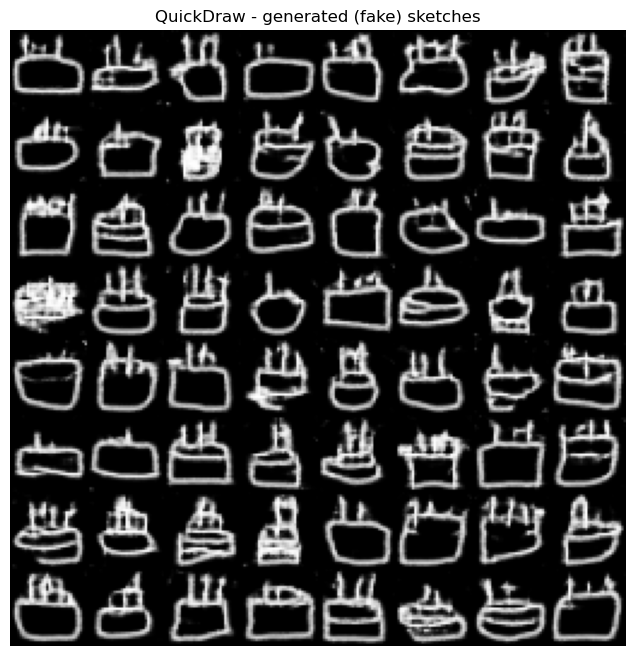

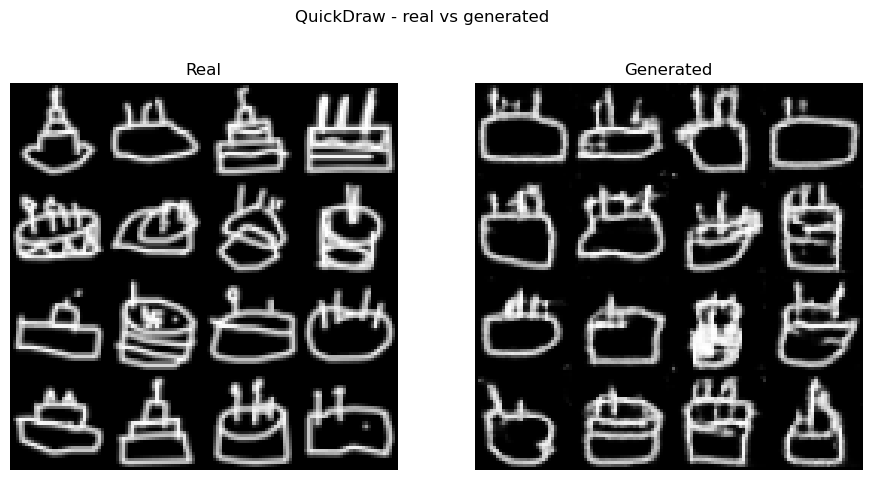

QuickDraw 'birthday cake' DCGAN FID (lower is better): 47.61


In [29]:
fid_scorer = InceptionFidScorer()

cake_fake = cake_gan.synthesize(CAKE_FID_SAMPLES)
montage(cake_fake[:64], "QuickDraw - generated (fake) sketches",
        os.path.join(KERAS_RESULTS_DIR, "quickdraw_fake_samples.png"))
side_by_side(images_from_uint8(cake_uint8[:16]), cake_fake[:16],
             "QuickDraw - real vs generated", os.path.join(KERAS_RESULTS_DIR, "quickdraw_real_vs_fake.png"))

cake_fid_idx = np.random.permutation(len(cake_uint8))[:CAKE_FID_SAMPLES]
cake_fid = fid_scorer.score(unit_from_signed(images_from_uint8(cake_uint8[cake_fid_idx])),
                            unit_from_signed(cake_fake))
print(f"QuickDraw 'birthday cake' DCGAN FID (lower is better): {cake_fid:.2f}")

## Other categories and sketch complexity (extension)

The same Keras DCGAN is retrained on a couple more categories, and an ink-fraction complexity proxy is compared against the FID.

fetching cat
Epoch 1/35
117/117 - 9s - 78ms/step - d_loss: 0.5651 - g_loss: 2.8105
Epoch 2/35
117/117 - 1s - 10ms/step - d_loss: 0.4366 - g_loss: 4.3133
Epoch 3/35
117/117 - 1s - 10ms/step - d_loss: 0.4326 - g_loss: 3.8952
Epoch 4/35
117/117 - 1s - 10ms/step - d_loss: 0.4569 - g_loss: 3.9847
Epoch 5/35
117/117 - 1s - 10ms/step - d_loss: 0.4010 - g_loss: 3.9390
Epoch 6/35
117/117 - 1s - 10ms/step - d_loss: 0.4723 - g_loss: 3.6629
Epoch 7/35
117/117 - 1s - 10ms/step - d_loss: 0.5489 - g_loss: 3.1339
Epoch 8/35
117/117 - 1s - 10ms/step - d_loss: 0.6279 - g_loss: 2.8165
Epoch 9/35
117/117 - 1s - 10ms/step - d_loss: 0.6213 - g_loss: 2.6639
Epoch 10/35
117/117 - 1s - 10ms/step - d_loss: 0.6426 - g_loss: 2.6030
Epoch 11/35
117/117 - 1s - 10ms/step - d_loss: 0.6573 - g_loss: 2.6112
Epoch 12/35
117/117 - 1s - 10ms/step - d_loss: 0.6673 - g_loss: 2.4991
Epoch 13/35
117/117 - 1s - 10ms/step - d_loss: 0.7171 - g_loss: 2.4226
Epoch 14/35
117/117 - 1s - 10ms/step - d_loss: 0.7244 - g_loss: 2.3998
Ep

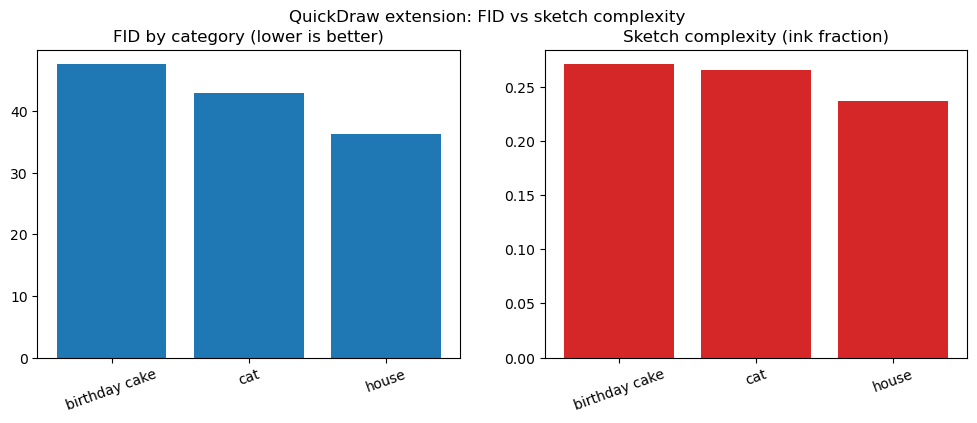

   birthday cake: FID=47.61 | ink=0.2708
             cat: FID=42.90 | ink=0.2655
           house: FID=36.33 | ink=0.2368


In [30]:
fid_by_category = {"birthday cake": cake_fid}
ink_by_category = {"birthday cake": ink_fraction(cake_uint8)}

for category in CAKE_EXTRA:
    keras.utils.set_random_seed(KERAS_SEED)
    category_uint8 = fetch_category(category)
    ink_by_category[category] = ink_fraction(category_uint8)
    category_idx = np.random.permutation(len(category_uint8))[:CAKE_MAX_IMAGES]
    category_dataset = (tf.data.Dataset.from_tensor_slices(images_from_uint8(category_uint8[category_idx]))
                        .shuffle(min(CAKE_MAX_IMAGES, 10000)).batch(CAKE_BATCH, drop_remainder=True)
                        .prefetch(tf.data.AUTOTUNE))
    category_gan = DcganModel(make_generator(CAKE_LATENT, CAKE_BASE, CAKE_INIT_STD),
                              make_discriminator(CAKE_BASE, CAKE_INIT_STD), latent_dim=CAKE_LATENT)
    category_gan.compile(d_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
                         g_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
                         loss_fn=keras.losses.BinaryCrossentropy(from_logits=True))
    category_gan.fit(category_dataset, epochs=CAKE_EPOCHS, verbose=2)
    category_fake = category_gan.synthesize(CAKE_FID_SAMPLES)
    category_ref = np.random.permutation(len(category_uint8))[:CAKE_FID_SAMPLES]
    fid_by_category[category] = fid_scorer.score(
        unit_from_signed(images_from_uint8(category_uint8[category_ref])), unit_from_signed(category_fake))
    print(f"QuickDraw '{category}': FID={fid_by_category[category]:.2f} | ink={ink_by_category[category]:.4f}")

labels = list(fid_by_category.keys())
figure, (ax_fid, ax_ink) = plt.subplots(1, 2, figsize=(12, 4))
ax_fid.bar(labels, [fid_by_category[k] for k in labels], color="#1f77b4")
ax_fid.set_title("FID by category (lower is better)"); ax_fid.tick_params(axis="x", rotation=20)
ax_ink.bar(labels, [ink_by_category[k] for k in labels], color="#d62728")
ax_ink.set_title("Sketch complexity (ink fraction)"); ax_ink.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs sketch complexity")
figure.savefig(os.path.join(KERAS_RESULTS_DIR, "quickdraw_extension_complexity.png"), dpi=150, bbox_inches="tight")
plt.show()
for k in labels:
    print(f"  {k:>14}: FID={fid_by_category[k]:.2f} | ink={ink_by_category[k]:.4f}")

## Reflection

The generated cakes are of reasonable quality. Most samples are clearly a cake: a rounded or rectangular body, candles poking out of the top, and often a plate underneath. The per-epoch grids show that shape forming early and then getting cleaner as the fit runs on. The usual line-art faults are visible on close inspection (broken strokes, the odd bit of background speckle), but nothing that hides what the drawing is meant to be, which fits an FID of 47.61.

Reading the fit history, `d_loss` and `g_loss` stay in a reasonable back-and-forth rather than one side running away, with only the occasional spike that doesn't hurt the samples.

Across categories the ranking is house (36.33), then cat (42.90), then cake (47.61), and the ink-fraction proxy happens to fall in the same order (0.237, 0.266, 0.271). The catch is that the ink numbers are almost identical while the FIDs clearly are not, so ink density isn't really doing the explaining here. What makes the cake hardest is the variety in how people draw it (different bodies, tiers and candle counts), not how many pixels get inked.

Same hallucination point ("ducks") as the other parts: the model can lay down fluent strokes that don't actually add up to a real object, so these sketches shouldn't be trusted as training data for something else without a look over them first.

# Key findings (summary)

Pulling the notebook together:

**Part 1** showed a from-scratch GAN learning a sine wave cleanly, reaching all eight modes of a Gaussian mixture (if loosely), and then sharpening those samples noticeably once the generator was made deeper and wider with SELU.

**Part 2.1** trained a DCGAN that produces plausible OCT scans (FID 50.38) and a conditional version that can be asked for a specific diagnostic class, with class-balanced sampling handling the dataset's imbalance.

**Part 2.2** built a dense feature-vector GAN (not a conv net, since the data are tabular flows) on the Wednesday BENIGN-vs-DoS split. PCA/t-SNE and the mean/std gaps show the synthetic traffic matching the bulk of the real distribution while missing the tails, and the all-days extension confirms one GAN struggles to span every attack family.

**Part 2.3** trained a Keras DCGAN on QuickDraw cakes (FID 47.61) plus two more categories, where the cross-category comparison shows difficulty comes from shape variety rather than raw ink density.

Every figure and FID number quoted in the report comes straight out of this notebook.

## Save everything to `results_set2/` and zip it

All the figures above are written to `results_set2/`. This last cell also collects any stray PNGs from the working directory and zips the folder as `results_set2.zip`.

In [48]:
import os
import glob
import shutil

RESULTS_DIR = "results_set2"
os.makedirs(RESULTS_DIR, exist_ok=True)

# move any figures from the working directory into the results folder
for figure_path in glob.glob("*.png"):
    shutil.move(figure_path, os.path.join(RESULTS_DIR, os.path.basename(figure_path)))

zip_archive_path = shutil.make_archive("results_set2", "zip", RESULTS_DIR)
print("All outputs saved in :", os.path.abspath(RESULTS_DIR))
print("Zipped archive       :", os.path.abspath(zip_archive_path))

All outputs saved in : /home/ec2-user/SageMaker/results_set2
Zipped archive       : /home/ec2-user/SageMaker/results_set2.zip
